# 14. Empirical data audit and alignment feasibility (USDJPY)

## 0. Notebook contract

This is the first real-data notebook after the completed synthetic workflow. Its sole purpose is to audit the raw empirical sources and establish whether they can later be aligned. The initial scope is **USDJPY only**. The new long-history hourly **midpoint** file is the selected intraday spot source; the 15-minute data and `USD_JPY_intraday15min.ipynb` are intentionally excluded.

The sources audited are the new hourly midpoint/bid/ask files, the supplementary legacy daily and hourly spot workbooks, the USDJPY ATM-volatility workbook (with 1D/overnight as the intended series), the G10 macro calendar, and the dedicated BoJ calendar. RR/BF workbooks are inventoried only. Equation (5), volatility-surface interpolation, modelling, realised variance, returns, event features, event-weight estimation, causality, forecasting, and trading analysis are all outside this notebook.

> **Audit/alignment here ≠ model-variable construction.** Notebook 15 will construct the empirical variables after the evidence below has been reviewed.


## 1. Imports, paths and reproducibility

Paths are deliberately simple and relative to the `Linus' Task Re-Do` working directory. Raw-file hashes provide an integrity check before and after the audit.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import platform
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Markdown
except ImportError:  # permits scripted validation in a minimal Python environment
    def display(value):
        print(str(value).encode('ascii', 'backslashreplace').decode('ascii'))
    Markdown = str

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'Data'
HOURLY_DIR = DATA_DIR / 'usdjpy_hourly_data'
HOURLY_MID_PATH = HOURLY_DIR / 'usdjpy_hourly_mid.csv'
HOURLY_BID_PATH = HOURLY_DIR / 'usdjpy_hourly_bid.csv'
HOURLY_ASK_PATH = HOURLY_DIR / 'usdjpy_hourly_ask.csv'
ATM_PATH = DATA_DIR / 'ATM_Volatility_-_all_currencies_diff_tenors.xlsx'
DAILY_SPOT_PATH = DATA_DIR / 'Currency Daily BidAskLast.xlsx'
OLD_HOURLY_PATH = DATA_DIR / 'Currency Hourly BidAskLast.xlsx'
G10_EVENTS_PATH = DATA_DIR / 'G10_events_merged_1997-2026.csv'
BOJ_EVENTS_PATH = DATA_DIR / 'boj_monetary_policy_meetings_2015_2026.csv'
RR_PATH = DATA_DIR / '25R - all currencies diff tenors.xlsx'
BF_PATH = DATA_DIR / '25B - all currencies diff tenors.xlsx'
INTERIM_DIR = DATA_DIR / 'interim'
PROCESSED_DIR = DATA_DIR / 'processed'

ATM_PRIMARY_TICKER = 'USDJPYVON BGN Curncy'
ATM_BLOOMBERG_FIELD = 'PX_LAST'

assert (PROJECT_DIR / 'Data').exists(), (
    "Run this notebook from the Linus' Task Re-Do project directory."
)
INTERIM_DIR.mkdir(exist_ok=True)

RAW_PATHS = {
    'hourly_mid': HOURLY_MID_PATH, 'hourly_bid': HOURLY_BID_PATH, 'hourly_ask': HOURLY_ASK_PATH,
    'atm': ATM_PATH, 'daily_spot': DAILY_SPOT_PATH, 'old_hourly': OLD_HOURLY_PATH,
    'g10_events': G10_EVENTS_PATH, 'boj_events': BOJ_EVENTS_PATH, 'rr': RR_PATH, 'bf': BF_PATH,
}
missing_files = [str(path) for path in RAW_PATHS.values() if not path.exists()]
assert not missing_files, f'Missing required raw files: {missing_files}'

def sha256_file(path, chunk_size=1_048_576):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

def parse_excel_dates(values):
    """Parse date cells while handling Excel serial dates without treating them as nanoseconds."""
    parsed = pd.to_datetime(values, errors='coerce')
    numeric = pd.to_numeric(values, errors='coerce')
    excel_serial = numeric.between(20_000, 60_000) & (parsed.isna() | parsed.dt.year.lt(1980))
    parsed.loc[excel_serial] = pd.to_datetime(numeric.loc[excel_serial], unit='D', origin='1899-12-30')
    return parsed

MAX_PLOT_GAP = pd.Timedelta(days=7)
def plot_observed_segments(ax, dates, values, *, label, max_gap=MAX_PLOT_GAP, **plot_kwargs):
    """Plot observed dates, connecting normal calendar gaps but breaking genuine source discontinuities."""
    plot_df = pd.DataFrame({'date': pd.to_datetime(dates), 'value': pd.to_numeric(values, errors='coerce')}).dropna()
    plot_df = plot_df.sort_values('date').drop_duplicates('date', keep='last').reset_index(drop=True)
    if plot_df.empty:
        return pd.DataFrame(columns=['previous_timestamp', 'next_timestamp', 'gap_days'])
    plot_df['segment_id'] = plot_df['date'].diff().gt(max_gap).cumsum()
    for i, (_, segment) in enumerate(plot_df.groupby('segment_id', sort=True)):
        ax.plot(segment['date'], segment['value'], label=label if i == 0 else '_nolegend_', **plot_kwargs)
    long_gaps = plot_df.loc[plot_df['date'].diff().gt(max_gap), ['date']].copy()
    long_gaps['previous_timestamp'] = plot_df['date'].shift().loc[long_gaps.index]
    long_gaps = long_gaps.rename(columns={'date': 'next_timestamp'})
    long_gaps['gap_days'] = (long_gaps['next_timestamp'] - long_gaps['previous_timestamp']) / pd.Timedelta(days=1)
    return long_gaps[['previous_timestamp', 'next_timestamp', 'gap_days']]

RAW_HASHES_BEFORE = {name: sha256_file(path) for name, path in RAW_PATHS.items()}
print(f'Working directory: {PROJECT_DIR}')
print(f'Python: {sys.version.split()[0]} | pandas: {pd.__version__} | platform: {platform.platform()}')
print(f'Audit run started (UTC): {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S %Z}')


Working directory: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do
Python: 3.14.5 | pandas: 2.3.3 | platform: Windows-11-10.0.26200-SP0
Audit run started (UTC): 2026-08-11 02:31:38 UTC


## 2. Source inventory

The inventory records all sources in scope without loading the excluded 15-minute data. Primary means selected for the revised implementation, not that a model variable is constructed here.


In [2]:
def excel_sheets(path):
    return ', '.join(pd.ExcelFile(path).sheet_names)

inventory_specs = [
    ('usdjpy_hourly_mid.csv', HOURLY_MID_PATH, 'CSV', 'Primary native Dukascopy 1-hour USDJPY midpoint candles', 'Primary'),
    ('usdjpy_hourly_bid.csv', HOURLY_BID_PATH, 'CSV', 'Bid-side cross-check for hourly midpoint', 'Supplementary / audit'),
    ('usdjpy_hourly_ask.csv', HOURLY_ASK_PATH, 'CSV', 'Ask-side cross-check for hourly midpoint', 'Supplementary / audit'),
    ('ATM volatility workbook', ATM_PATH, 'XLSX', 'Bloomberg PX_LAST for USDJPYVON BGN Curncy; primary USDJPY 1D/overnight ATM IV', 'Primary'),
    ('G10 macro calendar', G10_EVENTS_PATH, 'CSV', 'USD and JPY scheduled macro events', 'Primary'),
    ('Dedicated BoJ calendar', BOJ_EVENTS_PATH, 'CSV', 'BoJ meeting-date/timezone cross-check; not primary release timestamp', 'Supplementary / audit'),
    ('Daily bid/ask/last workbook', DAILY_SPOT_PATH, 'XLSX', 'Supplementary daily USDJPY cross-check', 'Supplementary / audit'),
    ('Legacy hourly bid/ask/last workbook', OLD_HOURLY_PATH, 'XLSX', 'Supplementary hourly USDJPY cross-check', 'Supplementary / audit'),
    ('25R workbook', RR_PATH, 'XLSX', 'Broader options dataset; not required for ATM 1D workflow', 'Supplementary / inventory only'),
    ('25B workbook', BF_PATH, 'XLSX', 'Broader options dataset; not required for ATM 1D workflow', 'Supplementary / inventory only'),
    ('usdjpy_15min_data/', DATA_DIR / 'usdjpy_15min_data', 'Directory', 'Explicitly excluded from current workflow', 'Excluded'),
    ('USD_JPY_intraday15min.ipynb', DATA_DIR / 'USD_JPY_intraday15min.ipynb', 'Notebook', 'Explicitly excluded from current workflow', 'Excluded'),
]
inventory_rows = []
for name, path, file_type, role, status in inventory_specs:
    row = {'source_name': name, 'path': str(path.relative_to(PROJECT_DIR)), 'file_type': file_type,
           'size_bytes': path.stat().st_size if path.is_file() else np.nan, 'sheets': '',
           'intended_role': role, 'status': status}
    if path.suffix.lower() == '.xlsx':
        row['sheets'] = excel_sheets(path)
    inventory_rows.append(row)
source_inventory = pd.DataFrame(inventory_rows)
display(source_inventory)
print('Conclusion: hourly midpoint, USDJPY 1D ATM IV and the G10 calendar are primary audit inputs; the dedicated BoJ calendar is a supplementary meeting-date/timezone cross-check. No 15-minute source is loaded.')


,source_name,path,file_type,size_bytes,sheets,intended_role,status
0,usdjpy_hourly_mid.csv,Data\usdjpy_hourly_data\usdjpy_hourly_mid.csv,CSV,17122983.0,,Primary native Dukascopy 1-hour USDJPY midpoin...,Primary
1,usdjpy_hourly_bid.csv,Data\usdjpy_hourly_data\usdjpy_hourly_bid.csv,CSV,9762180.0,,Bid-side cross-check for hourly midpoint,Supplementary / audit
2,usdjpy_hourly_ask.csv,Data\usdjpy_hourly_data\usdjpy_hourly_ask.csv,CSV,9759772.0,,Ask-side cross-check for hourly midpoint,Supplementary / audit
3,ATM volatility workbook,Data\ATM_Volatility_-_all_currencies_diff_teno...,XLSX,10396096.0,"Overnight, 1W, 2W, 1M, 2M, 3M, 6M, 1Y",Bloomberg PX_LAST for USDJPYVON BGN Curncy; pr...,Primary
4,G10 macro calendar,Data\G10_events_merged_1997-2026.csv,CSV,5339382.0,,USD and JPY scheduled macro events,Primary
5,Dedicated BoJ calendar,Data\boj_monetary_policy_meetings_2015_2026.csv,CSV,7625.0,,BoJ meeting-date/timezone cross-check; not pri...,Supplementary / audit
6,Daily bid/ask/last workbook,Data\Currency Daily BidAskLast.xlsx,XLSX,3673167.0,Sheet1,Supplementary daily USDJPY cross-check,Supplementary / audit
7,Legacy hourly bid/ask/last workbook,Data\Currency Hourly BidAskLast.xlsx,XLSX,2267715.0,Sheet1,Supplementary hourly USDJPY cross-check,Supplementary / audit
8,25R workbook,Data\25R - all currencies diff tenors.xlsx,XLSX,5050212.0,"1M, 3M, 6M, 1Y",Broader options dataset; not required for ATM ...,Supplementary / inventory only
9,25B workbook,Data\25B - all currencies diff tenors.xlsx,XLSX,4597752.0,"1W, 1M, 3M, 6M",Broader options dataset; not required for ATM ...,Supplementary / inventory only


Conclusion: hourly midpoint, USDJPY 1D ATM IV and the G10 calendar are primary audit inputs; the dedicated BoJ calendar is a supplementary meeting-date/timezone cross-check. No 15-minute source is loaded.


### RR/BF inventory quarantine

RR/BF remain outside the ATM-only workflow. The 25B 1W sheet is checked only to record a known provenance issue, not to construct any option variable.


In [3]:
bf_1w_header = pd.read_excel(BF_PATH, sheet_name='1W', header=None, nrows=2)
bf_1w_ticker_text = ' | '.join(bf_1w_header.iloc[1].dropna().astype(str))
bf_1w_appears_rr = '25R1W' in bf_1w_ticker_text.upper()
bf_1w_quarantine = pd.DataFrame([{
    'workbook': BF_PATH.name, 'sheet': '1W', 'observed_ticker_pattern': '25R1W-style' if bf_1w_appears_rr else 'pattern not detected',
    'status': 'QUARANTINED' if bf_1w_appears_rr else 'REVIEW REQUIRED',
    'handling': 'Do not use as 1W butterfly data without source resolution.',
}])
display(bf_1w_quarantine)


,workbook,sheet,observed_ticker_pattern,status,handling
0,25B - all currencies diff tenors.xlsx,1W,25R1W-style,QUARANTINED,Do not use as 1W butterfly data without source...


## 3. New USDJPY hourly midpoint source

The actual schema is inspected before assigning meanings. Any supplied return is treated only as a diagnostic field: it is not adopted as the eventual return series. A multi-hour gap is never interpreted here as a legitimate hourly observation.


In [4]:
mid_raw = pd.read_csv(HOURLY_MID_PATH)
print('Raw midpoint columns and dtypes:')
display(mid_raw.dtypes.rename('dtype').to_frame())
display(mid_raw.isna().sum().rename('missing_values').to_frame())
timestamp_col = next((c for c in mid_raw.columns if 'time' in c.lower() or 'date' in c.lower()), None)
assert timestamp_col is not None, 'No timestamp-like column found in hourly midpoint CSV.'
mid = mid_raw.copy()
mid['timestamp_parsed'] = pd.to_datetime(mid[timestamp_col], utc=True, errors='coerce')
close_col = next((c for c in mid.columns if c.lower() in {'mid_close', 'close', 'mid'}), None)
assert close_col is not None, 'No close/midpoint price column found in hourly midpoint CSV.'
mid[close_col] = pd.to_numeric(mid[close_col], errors='coerce')
ohlc_cols = {'open': 'mid_open', 'high': 'mid_high', 'low': 'mid_low', 'close': close_col}
assert all(column in mid.columns for column in ohlc_cols.values()), 'Expected hourly midpoint OHLC fields are absent.'
for column in ohlc_cols.values():
    mid[column] = pd.to_numeric(mid[column], errors='coerce')
ohlc_integrity = pd.DataFrame([{
    'high_below_low': int((mid['mid_high'] < mid['mid_low']).sum()),
    'high_below_open': int((mid['mid_high'] < mid['mid_open']).sum()),
    'high_below_close': int((mid['mid_high'] < mid[close_col]).sum()),
    'low_above_open': int((mid['mid_low'] > mid['mid_open']).sum()),
    'low_above_close': int((mid['mid_low'] > mid[close_col]).sum()),
}])
spread_col = next((c for c in mid.columns if 'spread' in c.lower()), None)
if spread_col:
    mid[spread_col] = pd.to_numeric(mid[spread_col], errors='coerce')
    supplied_spread_integrity = pd.DataFrame([{
        'spread_column': spread_col, 'negative_spreads': int(mid[spread_col].lt(0).sum()),
        'zero_spreads': int(mid[spread_col].eq(0).sum()), 'missing_spreads': int(mid[spread_col].isna().sum()),
    }])
    supplied_negative_spreads = mid.loc[mid[spread_col].lt(0), ['timestamp_parsed', 'mid_open', 'mid_high', 'mid_low', close_col, spread_col]].copy()
else:
    supplied_spread_integrity = pd.DataFrame([{'spread_column': None, 'negative_spreads': np.nan, 'zero_spreads': np.nan, 'missing_spreads': np.nan}])
    supplied_negative_spreads = pd.DataFrame()
display(ohlc_integrity)
display(supplied_spread_integrity)
display(supplied_negative_spreads.head(20))
mid = mid.sort_values('timestamp_parsed').reset_index(drop=True)
mid['timestamp_diff'] = mid['timestamp_parsed'].diff()
mid['is_adjacent_hour_diagnostic'] = mid['timestamp_diff'].eq(pd.Timedelta(hours=1))

interval_minutes = mid['timestamp_diff'].dt.total_seconds().div(60)
gap_mask = mid['timestamp_diff'].gt(pd.Timedelta(hours=1))
previous_timestamp = mid['timestamp_parsed'].shift()
# Friday-to-Sunday/Monday multi-hour breaks are normal FX-market closures, not unexpected missing observations.
expected_weekend_gap = (gap_mask & previous_timestamp.dt.dayofweek.eq(4)
                        & mid['timestamp_parsed'].dt.dayofweek.isin([6, 0])
                        & mid['timestamp_diff'].between(pd.Timedelta(days=1), pd.Timedelta(days=4)))
major_discontinuity_mask = mid['timestamp_diff'].gt(pd.Timedelta(days=7))
unexpected_weekday_gap = gap_mask & ~expected_weekend_gap & ~major_discontinuity_mask
# Major breaks define distinct continuous-coverage segments; the broad start/end span is not assumed continuous.
mid['major_coverage_segment'] = major_discontinuity_mask.cumsum()
hourly_coverage_segments = (mid.groupby('major_coverage_segment', as_index=False)
                            .agg(segment_start_utc=('timestamp_parsed', 'min'), segment_end_utc=('timestamp_parsed', 'max'), observations=('timestamp_parsed', 'size')))
mid['gap_classification'] = np.select(
    [mid['timestamp_diff'].isna(), mid['timestamp_diff'].eq(pd.Timedelta(hours=1)), expected_weekend_gap, major_discontinuity_mask, unexpected_weekday_gap],
    ['first observation / no predecessor', 'adjacent hour', 'expected Friday-to-Sunday/Monday closure', 'major historical discontinuity', 'short unexpected weekday/other gap'],
    default='other interval',
)
midpoint_summary = pd.DataFrame([{
    'rows': len(mid), 'timestamp_column': timestamp_col, 'close_column': close_col,
    'timestamp_start_utc': mid['timestamp_parsed'].min(), 'timestamp_end_utc': mid['timestamp_parsed'].max(),
    'unparseable_timestamps': int(mid['timestamp_parsed'].isna().sum()),
    'duplicate_timestamps': int(mid['timestamp_parsed'].duplicated().sum()),
    'input_timestamp_monotonic': bool(pd.to_datetime(mid_raw[timestamp_col], utc=True, errors='coerce').is_monotonic_increasing),
    'missing_close': int(mid[close_col].isna().sum()), 'non_positive_close': int(mid[close_col].le(0).sum()),
    'gaps_over_one_hour_total': int(gap_mask.sum()), 'expected_weekend_market_closures': int(expected_weekend_gap.sum()),
    'short_unexpected_weekday_or_other_gaps': int(unexpected_weekday_gap.sum()),
    'major_historical_discontinuities_over_7_days': int(major_discontinuity_mask.sum()),
    'continuous_coverage_segments_separated_by_major_breaks': len(hourly_coverage_segments),
    'broad_dataset_span_days': (mid['timestamp_parsed'].max() - mid['timestamp_parsed'].min()) / pd.Timedelta(days=1),
    'largest_gap_hours': interval_minutes.max() / 60,
    'weekend_observations': int((mid['timestamp_parsed'].dt.dayofweek >= 5).sum()),
}])
display(midpoint_summary)
display(interval_minutes.value_counts(dropna=True).head(12).rename_axis('interval_minutes').reset_index(name='count'))
display(mid.loc[gap_mask, ['timestamp_parsed', 'timestamp_diff', 'gap_classification', close_col]].head(15))
display(mid.loc[unexpected_weekday_gap, ['timestamp_parsed', 'timestamp_diff', close_col]].head(15))

daily_observation_counts = (mid.dropna(subset=['timestamp_parsed']).assign(calendar_date=lambda x: x['timestamp_parsed'].dt.date)
                           .groupby('calendar_date').size().rename('observations').reset_index())
display(daily_observation_counts['observations'].describe().to_frame('observations_per_calendar_day'))
# Very large breaks are shown separately: they are not repaired or treated as valid hourly adjacency.
historical_discontinuities = mid.loc[major_discontinuity_mask, ['timestamp_parsed', 'timestamp_diff', close_col]].copy()
major_hourly_outages = historical_discontinuities.assign(
    outage_start_utc=lambda x: x['timestamp_parsed'] - x['timestamp_diff'],
    outage_end_utc=lambda x: x['timestamp_parsed'],
    outage_days=lambda x: x['timestamp_diff'] / pd.Timedelta(days=1),
)[['outage_start_utc', 'outage_end_utc', 'outage_days']]
display(historical_discontinuities.head(20))
display(major_hourly_outages)
major_outage_description = 'No discontinuity longer than seven days was found.'
if not historical_discontinuities.empty:
    largest_break = historical_discontinuities.loc[historical_discontinuities['timestamp_diff'].idxmax()]
    major_outage_description = (f"{largest_break['timestamp_parsed'] - largest_break['timestamp_diff']:%Y-%m-%d %H:%M UTC} to "
                                f"{largest_break['timestamp_parsed']:%Y-%m-%d %H:%M UTC} ({largest_break['timestamp_diff'] / pd.Timedelta(days=1):.1f} days)")
    print(f"Major discontinuity: {largest_break['timestamp_diff'] / pd.Timedelta(days=1):.1f} days ending {largest_break['timestamp_parsed']:%Y-%m-%d %H:%M UTC}.")
print(f"Broad hourly date span: {mid['timestamp_parsed'].min():%Y-%m-%d} to {mid['timestamp_parsed'].max():%Y-%m-%d}; continuous coverage is split into {len(hourly_coverage_segments)} segments by the major outage(s).")
print('Gap interpretation: ordinary Friday-to-Sunday/Monday closures are separated from short weekday/other gaps; breaks over seven days are major historical discontinuities.')

return_cols = [c for c in mid.columns if 'return' in c.lower()]
if return_cols:
    supplied_return_col = return_cols[0]
    supplied_on_gap = int((gap_mask & mid[supplied_return_col].notna()).sum())
    supplied_return_diagnostic = pd.DataFrame([{
        'supplied_return_column': supplied_return_col, 'non_missing_supplied_returns': int(mid[supplied_return_col].notna().sum()),
        'supplied_returns_across_gaps_over_one_hour': supplied_on_gap,
        'diagnostic_conclusion': 'FLAG: supplied return exists across a non-adjacent gap' if supplied_on_gap else 'No supplied returns found across >1h gaps',
    }])
    display(supplied_return_diagnostic)
    print('Conclusion: supplied returns are not accepted for Notebook 15. Hourly returns will be recomputed there with an explicit adjacency rule.')
else:
    supplied_return_diagnostic = pd.DataFrame([{'supplied_return_column': None, 'non_missing_supplied_returns': 0, 'supplied_returns_across_gaps_over_one_hour': 0, 'diagnostic_conclusion': 'No supplied return field'}])
    print('Conclusion: no supplied return column was found; Notebook 15 will construct returns from prices with an adjacency rule.')


Raw midpoint columns and dtypes:


,dtype
timestamp,object
mid_open,float64
mid_high,float64
mid_low,float64
mid_close,float64
spread_close,float64
log_return,float64


,missing_values
timestamp,0
mid_open,0
mid_high,0
mid_low,0
mid_close,0
spread_close,0
log_return,0


,high_below_low,high_below_open,high_below_close,low_above_open,low_above_close
0,0,0,0,0,0


,spread_column,negative_spreads,zero_spreads,missing_spreads
0,spread_close,1,6,0


...

,timestamp_parsed,timestamp_diff,mid_close
42801,2010-10-01 10:00:00+00:00,273 days 10:00:00,83.185


,outage_start_utc,outage_end_utc,outage_days
42801,2010-01-01 00:00:00+00:00,2010-10-01 10:00:00+00:00,273.416667


Major discontinuity: 273.4 days ending 2010-10-01 10:00 UTC.
Broad hourly date span: 2003-05-04 to 2026-07-01; continuous coverage is split into 2 segments by the major outage(s).
Gap interpretation: ordinary Friday-to-Sunday/Monday closures are separated from short weekday/other gaps; breaks over seven days are major historical discontinuities.


,supplied_return_column,non_missing_supplied_returns,supplied_returns_across_gaps_over_one_hour,diagnostic_conclusion
0,log_return,149842,1106,FLAG: supplied return exists across a non-adja...


Conclusion: supplied returns are not accepted for Notebook 15. Hourly returns will be recomputed there with an explicit adjacency rule.


### Dukascopy hourly candle timing and reproducibility

The raw data were downloaded from Dukascopy at its native 1-hour candle interval, not manually resampled from smaller bars. For audit purposes, the UTC timestamp is treated as the candle **start/open** time: a row labelled `t` represents approximately `[t, t+1 hour)`, and its stored close belongs to the interval end. Thus a later adjacent-close return `log(C_t/C_{t-1})` must be aligned to events consistently with this interval convention; Notebook 15 will formalise interval start/end fields. The exact installed `dukascopy-python` version used for the historical extraction was not captured, which is a reproducibility limitation but does not alter the downloaded observations.


### Hourly-data completeness

Monthly observation counts are a descriptive availability check only. They do not construct returns or realised variance; they make extended outages and unusually thin months visible.


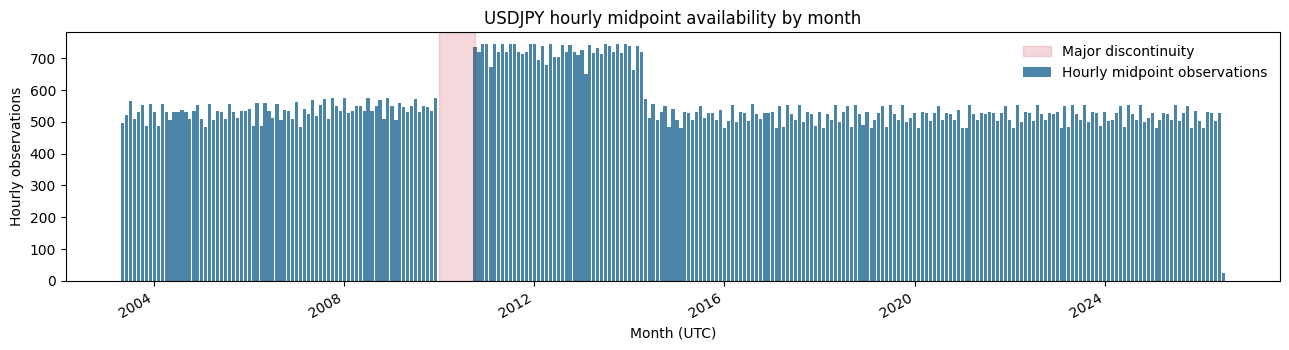

In [5]:
monthly_hourly_counts = (mid.dropna(subset=['timestamp_parsed']).set_index('timestamp_parsed').resample('MS').size())
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.bar(monthly_hourly_counts.index, monthly_hourly_counts.values, width=24, color='#2a6f97', alpha=0.85, label='Hourly midpoint observations')
for i, (_, row) in enumerate(historical_discontinuities.iterrows()):
    gap_end = row['timestamp_parsed']
    gap_start = gap_end - row['timestamp_diff']
    ax.axvspan(gap_start, gap_end, color='#c1121f', alpha=0.16, label='Major discontinuity' if i == 0 else None)
ax.set_title('USDJPY hourly midpoint availability by month')
ax.set_ylabel('Hourly observations')
ax.set_xlabel('Month (UTC)')
ax.legend(loc='upper right', frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Routine FX weekend closures are expected market structure, not data errors. Short irregular weekday gaps also exist, but the extended 2010 outage is materially different: later return, realised-variance, and lagged-observation construction must not bridge it. No missing observations are filled here.


### Weekend and stale-quote audit

The timestamp strings are already established as UTC. This diagnostic tests whether elevated observation counts reflect populated weekend timestamps with unchanged prices. It does not declare every weekend observation invalid and does not apply a cleaning rule in this notebook.


In [6]:
weekend_audit = mid[['timestamp_parsed', close_col]].copy()
weekend_audit['year'] = weekend_audit['timestamp_parsed'].dt.year
weekend_audit['weekday_number'] = weekend_audit['timestamp_parsed'].dt.dayofweek
weekend_audit['weekday_name'] = weekend_audit['timestamp_parsed'].dt.day_name()
weekend_audit['is_saturday'] = weekend_audit['weekday_number'].eq(5)
weekend_audit['is_sunday'] = weekend_audit['weekday_number'].eq(6)
weekend_audit['is_weekday'] = weekend_audit['weekday_number'].lt(5)
weekend_audit['is_weekend'] = weekend_audit['weekday_number'].ge(5)
weekend_audit['adjacent_hour'] = mid['timestamp_diff'].eq(pd.Timedelta(hours=1))
# Exact equality is a transparent carry-forward screen; the strict indicator also requires a true adjacent hour.
weekend_audit['unchanged_from_previous_row'] = weekend_audit[close_col].eq(weekend_audit[close_col].shift())
weekend_audit['unchanged_adjacent_hour'] = weekend_audit['adjacent_hour'] & weekend_audit['unchanged_from_previous_row']
weekday_observation_counts = (weekend_audit['weekday_name'].value_counts()
                              .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
                              .rename_axis('weekday').reset_index(name='hourly_observations'))
weekend_stale_by_year = (weekend_audit.groupby('year', as_index=False)
                         .agg(total_hourly_rows=(close_col, 'size'), weekday_rows=('is_weekday', 'sum'), weekend_rows=('is_weekend', 'sum'),
                              saturday_rows=('is_saturday', 'sum'), sunday_rows=('is_sunday', 'sum'),
                              saturday_adjacent_unchanged=('unchanged_adjacent_hour', lambda s: int((s & weekend_audit.loc[s.index, 'is_saturday']).sum())),
                              sunday_adjacent_unchanged=('unchanged_adjacent_hour', lambda s: int((s & weekend_audit.loc[s.index, 'is_sunday']).sum()))))
weekend_stale_by_year['saturday_adjacent_unchanged_pct'] = 100 * weekend_stale_by_year['saturday_adjacent_unchanged'] / weekend_stale_by_year['saturday_rows'].replace(0, np.nan)
weekend_stale_by_year['sunday_adjacent_unchanged_pct'] = 100 * weekend_stale_by_year['sunday_adjacent_unchanged'] / weekend_stale_by_year['sunday_rows'].replace(0, np.nan)
weekend_stale_by_year['weekend_share_pct'] = 100 * weekend_stale_by_year['weekend_rows'] / weekend_stale_by_year['total_hourly_rows']
weekend_rows = weekend_audit.loc[weekend_audit['is_weekend']]
weekend_stale_summary = pd.DataFrame([{
    'total_hourly_rows': len(weekend_audit), 'weekend_rows': len(weekend_rows), 'weekend_share_pct': 100 * len(weekend_rows) / len(weekend_audit),
    'saturday_rows': int(weekend_audit['is_saturday'].sum()), 'sunday_rows': int(weekend_audit['is_sunday'].sum()),
    'saturday_adjacent_unchanged_pct': 100 * weekend_audit.loc[weekend_audit['is_saturday'], 'unchanged_adjacent_hour'].mean(),
    'sunday_adjacent_unchanged_pct': 100 * weekend_audit.loc[weekend_audit['is_sunday'], 'unchanged_adjacent_hour'].mean(),
    'weekend_adjacent_unchanged_pct': 100 * weekend_rows['unchanged_adjacent_hour'].mean(),
}])
display(weekday_observation_counts)
display(weekend_stale_by_year)
display(weekend_stale_summary)
material_weekend_years = weekend_stale_by_year.loc[weekend_stale_by_year['weekend_share_pct'].gt(10), 'year'].tolist()
material_weekend_year_label = ', '.join(map(str, material_weekend_years)) if material_weekend_years else 'none under the stated threshold'
stale_regime = weekend_stale_by_year.loc[weekend_stale_by_year['year'].between(2011, 2013)]
weekend_stale_description = (f"Weekend timestamps account for {weekend_stale_summary.iloc[0]['weekend_share_pct']:.1f}% of all rows; "
                            f"Saturday adjacent-hour unchanged quotes are {weekend_stale_summary.iloc[0]['saturday_adjacent_unchanged_pct']:.1f}% overall and "
                            f"Sunday adjacent-hour unchanged quotes are {weekend_stale_summary.iloc[0]['sunday_adjacent_unchanged_pct']:.1f}% overall; materially populated weekend years are {material_weekend_year_label}.")
if not stale_regime.empty:
    print(f"2011–2013 regime: Saturday adjacent-hour unchanged quotes range from {stale_regime['saturday_adjacent_unchanged_pct'].min():.1f}% to {stale_regime['saturday_adjacent_unchanged_pct'].max():.1f}%; Sunday adjacent-hour unchanged quotes range from {stale_regime['sunday_adjacent_unchanged_pct'].min():.1f}% to {stale_regime['sunday_adjacent_unchanged_pct'].max():.1f}%.")
print(f"Conclusion: materially populated weekend years (weekend share >10%) are {material_weekend_year_label}; the regime is particularly strong in 2011–2013. This does not justify removing every zero return: a valid open-market hourly quote may genuinely be unchanged.")


,weekday,hourly_observations
0,Monday,27984
1,Tuesday,28021
2,Wednesday,27996
3,Thursday,27973
4,Friday,25730
5,Saturday,4451
6,Sunday,7687


,year,total_hourly_rows,weekday_rows,weekend_rows,saturday_rows,sunday_rows,saturday_adjacent_unchanged,sunday_adjacent_unchanged,saturday_adjacent_unchanged_pct,sunday_adjacent_unchanged_pct,weekend_share_pct
0,2003,4221,4101,120,0,120,0,0,NaN,0.000000,2.842928
1,2004,6336,6182,154,0,154,0,0,NaN,0.000000,2.430556
2,2005,6297,6141,156,0,156,0,0,NaN,0.000000,2.477370
3,2006,6321,6152,169,0,169,0,0,NaN,0.000000,2.673628
4,2007,6492,6173,319,0,319,0,11,NaN,3.448276,4.913740
5,2008,6579,6202,377,0,377,0,13,NaN,3.448276,5.730354
6,2009,6554,6177,377,1,376,0,14,0.000000,3.723404,5.752212
7,2010,2199,1575,624,312,312,312,282,100.000000,90.384615,28.376535
8,2011,8729,6240,2489,1262,1227,1261,1089,99.920761,88.753056,28.514148
9,2012,8637,6246,2391,1214,1177,1211,1032,99.752883,87.680544,27.683223


,total_hourly_rows,weekend_rows,weekend_share_pct,saturday_rows,sunday_rows,saturday_adjacent_unchanged_pct,sunday_adjacent_unchanged_pct,weekend_adjacent_unchanged_pct
0,149842,12138,8.100533,4451,7687,99.595596,50.149603,68.28143


2011–2013 regime: Saturday adjacent-hour unchanged quotes range from 99.4% to 99.9%; Sunday adjacent-hour unchanged quotes range from 87.4% to 88.8%.
Conclusion: materially populated weekend years (weekend share >10%) are 2010, 2011, 2012, 2013, 2014; the regime is particularly strong in 2011–2013. This does not justify removing every zero return: a valid open-market hourly quote may genuinely be unchanged.


Routine weekend closures, populated weekend/stale timestamps, and the major 2010 source outage are different phenomena. FX is not genuinely continuously trading through Saturday and most of Sunday, and the precise reopening boundary is DST-sensitive; populated weekend rows therefore cannot automatically be treated as valid activity. Notebook 15 must determine a valid trading-hour/day mask before aggregating squared adjacent returns, without simply deleting every zero return.

> **Notebook 15 measurement-contract decision.** A future daily close-to-close return can include a Friday-to-Monday closure/reopening movement, whereas realised variance from valid adjacent within-session hourly returns may not. Consequently a closure-day identity such as `r_t = Σ_h r_{t,h}` can fail unless closure-gap handling is explicitly defined. Potential concepts—within-session return, closure-gap return, cut-to-cut return, and within-session RV—are not constructed here.


In [7]:
def audit_new_quote_csv(path, label):
    frame = pd.read_csv(path)
    ts_col = next(c for c in frame.columns if 'time' in c.lower() or 'date' in c.lower())
    close = next(c for c in frame.columns if c.lower() == 'close')
    frame['timestamp_parsed'] = pd.to_datetime(frame[ts_col], utc=True, errors='coerce')
    frame[close] = pd.to_numeric(frame[close], errors='coerce')
    frame = frame.sort_values('timestamp_parsed')
    intervals = frame['timestamp_parsed'].diff().dt.total_seconds().div(60)
    summary = {'source': label, 'rows': len(frame), 'start_utc': frame['timestamp_parsed'].min(), 'end_utc': frame['timestamp_parsed'].max(),
               'unparseable_timestamps': int(frame['timestamp_parsed'].isna().sum()), 'duplicate_timestamps': int(frame['timestamp_parsed'].duplicated().sum()),
               'missing_close': int(frame[close].isna().sum()), 'non_positive_close': int(frame[close].le(0).sum()),
               'modal_interval_minutes': intervals.mode().iloc[0] if not intervals.mode().empty else np.nan}
    return frame[['timestamp_parsed', close]].rename(columns={close: f'{label}_close'}), summary

bid, bid_summary = audit_new_quote_csv(HOURLY_BID_PATH, 'bid')
ask, ask_summary = audit_new_quote_csv(HOURLY_ASK_PATH, 'ask')
display(pd.DataFrame([bid_summary, ask_summary]))
quote_overlap = (mid[['timestamp_parsed', close_col]].rename(columns={close_col: 'mid_close'})
                 .merge(bid, on='timestamp_parsed', how='inner').merge(ask, on='timestamp_parsed', how='inner'))
quote_overlap['crossed_close'] = quote_overlap['bid_close'] > quote_overlap['ask_close']
quote_overlap['bid_ask_close_spread'] = quote_overlap['ask_close'] - quote_overlap['bid_close']
quote_overlap['mid_minus_bidask_average'] = quote_overlap['mid_close'] - (quote_overlap['bid_close'] + quote_overlap['ask_close']) / 2
quote_consistency = pd.DataFrame([{
    'all_three_overlap_rows': len(quote_overlap), 'crossed_bid_ask_close_quotes': int(quote_overlap['crossed_close'].sum()),
    'negative_bid_ask_close_spreads': int(quote_overlap['bid_ask_close_spread'].lt(0).sum()), 'zero_bid_ask_close_spreads': int(quote_overlap['bid_ask_close_spread'].eq(0).sum()),
    'median_mid_minus_bidask_average': quote_overlap['mid_minus_bidask_average'].median(),
    'max_abs_mid_minus_bidask_average': quote_overlap['mid_minus_bidask_average'].abs().max(),
}])
display(quote_consistency)
display(quote_overlap.loc[quote_overlap['crossed_close'], ['timestamp_parsed', 'bid_close', 'ask_close', 'mid_close', 'bid_ask_close_spread']])
print('Conclusion: bid/ask are retained as an audit cross-check only; no bid/ask cleaning model is built here.')


,source,rows,start_utc,end_utc,unparseable_timestamps,duplicate_timestamps,missing_close,non_positive_close,modal_interval_minutes
0,bid,149843,2003-05-04 17:00:00+00:00,2026-07-01 23:00:00+00:00,0,0,0,0,60.0
1,ask,149843,2003-05-04 17:00:00+00:00,2026-07-01 23:00:00+00:00,0,0,0,0,60.0


,all_three_overlap_rows,crossed_bid_ask_close_quotes,negative_bid_ask_close_spreads,zero_bid_ask_close_spreads,median_mid_minus_bidask_average,max_abs_mid_minus_bidask_average
0,149842,1,1,6,0.0,2.842171e-14


,timestamp_parsed,bid_close,ask_close,mid_close,bid_ask_close_spread
30774,2008-03-02 21:00:00+00:00,103.6,103.59,103.595,-0.01


Conclusion: bid/ask are retained as an audit cross-check only; no bid/ask cleaning model is built here.


## 4. Original daily and hourly spot workbooks

These legacy workbooks are supplementary. The extraction below searches their displayed USDJPY labels and reports their quality as found; it does not replace the new midpoint source or correct any crossed quote.


In [8]:
def extract_legacy_daily_usdjpy(path):
    raw = pd.read_excel(path, header=None)
    pair_positions = np.where(raw.iloc[3].astype(str).str.contains('USDJPY', case=False, na=False))[0]
    assert len(pair_positions), 'USDJPY label not found in daily workbook.'
    value_start = pair_positions[0]
    # This daily workbook has one shared date column at position 0, unlike the tenor workbooks.
    out = raw.iloc[6:, [0, value_start, value_start + 1, value_start + 2]].copy()
    out.columns = ['timestamp', 'bid', 'ask', 'last']
    out['timestamp'] = parse_excel_dates(out['timestamp'])
    for c in ['bid', 'ask', 'last']:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out.dropna(how='all')

def extract_legacy_hourly_usdjpy(path):
    raw = pd.read_excel(path, header=None)
    pair_positions = np.where(raw.iloc[2].astype(str).str.contains('USDJPY', case=False, na=False))[0]
    assert len(pair_positions) >= 1, 'USDJPY label not found in legacy hourly workbook.'
    pieces = []
    for position in pair_positions:
        quote_type = str(raw.iloc[0, position + 1]).strip().lower()
        piece = raw.iloc[4:, [position, position + 1]].copy()
        piece.columns = ['timestamp', quote_type]
        piece['timestamp'] = pd.to_datetime(piece['timestamp'], errors='coerce')
        piece[quote_type] = pd.to_numeric(piece[quote_type], errors='coerce')
        pieces.append(piece)
    result = pieces[0]
    for piece in pieces[1:]:
        result = result.merge(piece, on='timestamp', how='outer')
    return result.dropna(how='all')

daily_legacy = extract_legacy_daily_usdjpy(DAILY_SPOT_PATH)
hourly_legacy = extract_legacy_hourly_usdjpy(OLD_HOURLY_PATH)
print('Legacy daily USDJPY fields:', list(daily_legacy.columns))
print('Legacy hourly USDJPY fields:', list(hourly_legacy.columns))
def legacy_summary(frame, name, timestamp='timestamp'):
    price_cols = [c for c in frame.columns if c != timestamp]
    summary = {'source': name, 'rows': len(frame), 'start': frame[timestamp].min(), 'end': frame[timestamp].max(),
               'unparseable_timestamps': int(frame[timestamp].isna().sum()), 'duplicate_timestamps': int(frame[timestamp].duplicated().sum()),
               'missing_values': int(frame[price_cols].isna().sum().sum()),
               'non_positive_values': int(frame[price_cols].le(0).sum().sum())}
    if {'bid', 'ask'}.issubset(frame.columns):
        summary['crossed_bid_ask'] = int((frame['bid'] > frame['ask']).sum())
    return summary

legacy_spot_summary = pd.DataFrame([legacy_summary(daily_legacy, 'Legacy daily USDJPY'), legacy_summary(hourly_legacy, 'Legacy hourly USDJPY')])
display(legacy_spot_summary)
legacy_daily_crossed = daily_legacy.loc[daily_legacy['bid'] > daily_legacy['ask'], ['timestamp', 'bid', 'ask', 'last']]
display(legacy_daily_crossed.head(20))
new_hourly_dates = set(mid['timestamp_parsed'].dropna().dt.date)
legacy_overlap = pd.DataFrame([{
    'legacy_source': 'daily', 'overlap_calendar_dates_with_new_hourly': len(set(daily_legacy['timestamp'].dropna().dt.date) & new_hourly_dates),
}, {
    'legacy_source': 'hourly', 'overlap_calendar_dates_with_new_hourly': len(set(hourly_legacy['timestamp'].dropna().dt.date) & new_hourly_dates),
}])
display(legacy_overlap)
print('Conclusion: legacy spot files remain cross-check sources. Any crossed quotes are reported above and remain unaltered.')


Legacy daily USDJPY fields: ['timestamp', 'bid', 'ask', 'last']
Legacy hourly USDJPY fields: ['timestamp', 'trade', 'bid', 'ask']


,source,rows,start,end,unparseable_timestamps,duplicate_timestamps,missing_values,non_positive_values,crossed_bid_ask
0,Legacy daily USDJPY,10437,1986-06-10 00:00:00,2026-06-10 00:00:00,0,0,0,0,12
1,Legacy hourly USDJPY,3424,2025-11-25 22:00:00,2026-06-10 16:00:00,0,0,0,0,0


,timestamp,bid,ask,last
2935,1997-09-01,121.20,120.95,121.08
2939,1997-09-05,121.23,121.14,121.26
2952,1997-09-24,122.02,120.37,120.35
3264,1998-12-04,118.67,118.63,118.72
3283,1998-12-31,113.88,113.49,113.60
3285,1999-01-04,111.99,111.79,112.02
3398,1999-06-10,118.97,118.95,118.96
3403,1999-06-17,119.42,119.40,119.41
3416,1999-07-06,122.40,122.10,122.25
3482,1999-10-06,107.51,107.49,107.50


,legacy_source,overlap_calendar_dates_with_new_hourly
0,daily,5832
1,hourly,170


Conclusion: legacy spot files remain cross-check sources. Any crossed quotes are reported above and remain unaltered.


### USDJPY spot-source consistency check

The original daily workbook remains a supplementary validation source. For this descriptive comparison only, its bid/ask midpoint is used where both quotes are present (otherwise the audited last price is used) and is compared on overlapping calendar dates with the last available hourly midpoint. This is **not** final daily-return construction, does not resolve the daily quote cut, and does not patch missing intraday observations.


Daily source-comparison convention: bid/ask midpoint only when bid ≤ ask; audited last price is used for 12 crossed-quote date(s).


,overlap_days,start,end,level_correlation,median_absolute_level_difference,p99_absolute_level_difference
0,5832,2003-05-05,2026-06-10,0.999976,0.053,0.48207


,outage_start,outage_end,outage_days,original_daily_observations_during_outage,hourly_derived_daily_observations_strictly_inside_outage,last_hourly_derived_daily_observation_at_or_before_start,first_hourly_derived_daily_observation_at_or_after_end
0,2010-01-01,2010-10-01,273.416667,196,0,2010-01-01,2010-10-01


,series,previous_timestamp,next_timestamp,gap_days
0,Hourly midpoint → daily last,2010-01-01,2010-10-01,273.0


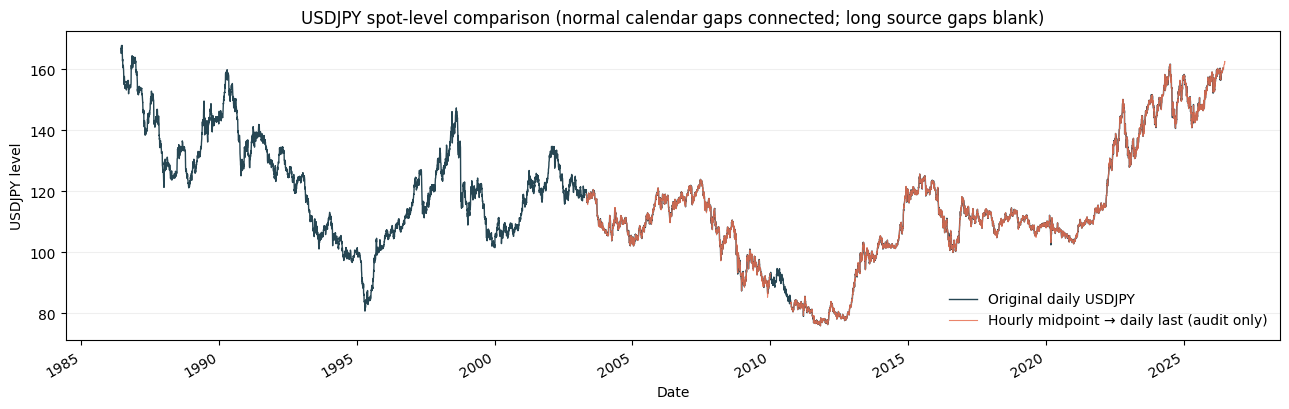

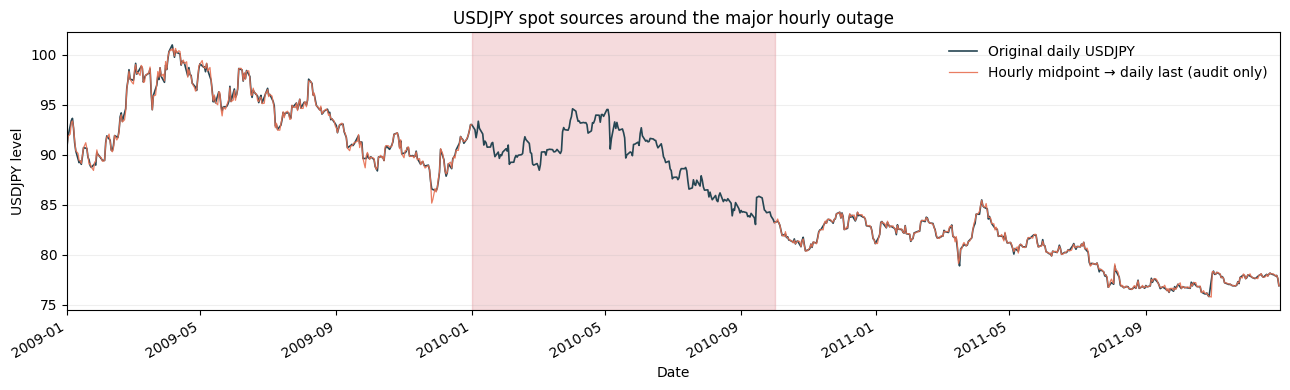

In [9]:
daily_legacy = daily_legacy.copy()
daily_has_bid_ask = daily_legacy['bid'].notna() & daily_legacy['ask'].notna() & daily_legacy['bid'].le(daily_legacy['ask'])
daily_legacy['original_daily_spot_audit'] = np.where(
    daily_has_bid_ask, (daily_legacy['bid'] + daily_legacy['ask']) / 2, daily_legacy['last']
)
daily_crossed_fallback_count = int((daily_legacy['bid'] > daily_legacy['ask']).sum())
print(f'Daily source-comparison convention: bid/ask midpoint only when bid ≤ ask; audited last price is used for {daily_crossed_fallback_count} crossed-quote date(s).')
hourly_daily_last_audit = (mid[['timestamp_parsed', close_col]].dropna().set_index('timestamp_parsed')[close_col]
                           .resample('D').last().rename('hourly_midpoint_daily_last').reset_index())
hourly_daily_last_audit['timestamp'] = hourly_daily_last_audit['timestamp_parsed'].dt.tz_localize(None).dt.normalize()
spot_source_comparison = (daily_legacy[['timestamp', 'original_daily_spot_audit']]
                          .dropna().merge(hourly_daily_last_audit[['timestamp', 'hourly_midpoint_daily_last']].dropna(), on='timestamp', how='inner')
                          .sort_values('timestamp').reset_index(drop=True))
spot_source_comparison['level_difference'] = (spot_source_comparison['original_daily_spot_audit'] - spot_source_comparison['hourly_midpoint_daily_last'])
source_consistency_summary = pd.DataFrame([{
    'overlap_days': len(spot_source_comparison), 'start': spot_source_comparison['timestamp'].min(), 'end': spot_source_comparison['timestamp'].max(),
    'level_correlation': spot_source_comparison['original_daily_spot_audit'].corr(spot_source_comparison['hourly_midpoint_daily_last']),
    'median_absolute_level_difference': spot_source_comparison['level_difference'].abs().median(),
    'p99_absolute_level_difference': spot_source_comparison['level_difference'].abs().quantile(0.99),
}])
display(source_consistency_summary)
outage_daily_coverage = []
for _, outage in major_hourly_outages.iterrows():
    start, end = outage['outage_start_utc'].tz_localize(None).normalize(), outage['outage_end_utc'].tz_localize(None).normalize()
    hourly_available = hourly_daily_last_audit.loc[hourly_daily_last_audit['hourly_midpoint_daily_last'].notna(), ['timestamp', 'hourly_midpoint_daily_last']]
    outage_daily_coverage.append({'outage_start': start, 'outage_end': end, 'outage_days': outage['outage_days'],
                                  'original_daily_observations_during_outage': int(daily_legacy['timestamp'].between(start, end).sum()),
                                  'hourly_derived_daily_observations_strictly_inside_outage': int(hourly_available['timestamp'].gt(start).mul(hourly_available['timestamp'].lt(end)).sum()),
                                  'last_hourly_derived_daily_observation_at_or_before_start': hourly_available.loc[hourly_available['timestamp'].le(start), 'timestamp'].max(),
                                  'first_hourly_derived_daily_observation_at_or_after_end': hourly_available.loc[hourly_available['timestamp'].ge(end), 'timestamp'].min()})
outage_daily_coverage = pd.DataFrame(outage_daily_coverage)
display(outage_daily_coverage)
# Plot original daily prices only on actual trading dates; the hourly series is split only at genuine long source gaps.
daily_plot = daily_legacy[['timestamp', 'original_daily_spot_audit']].dropna().sort_values('timestamp')
hourly_daily_plot = hourly_daily_last_audit[['timestamp', 'hourly_midpoint_daily_last']].dropna().sort_values('timestamp')
fig, ax = plt.subplots(figsize=(13, 4.2))
daily_plot_gaps = plot_observed_segments(ax, daily_plot['timestamp'], daily_plot['original_daily_spot_audit'], label='Original daily USDJPY', color='#264653', linewidth=1.0)
hourly_plot_gaps = plot_observed_segments(ax, hourly_daily_plot['timestamp'], hourly_daily_plot['hourly_midpoint_daily_last'], label='Hourly midpoint → daily last (audit only)', color='#e76f51', linewidth=0.8, alpha=0.85)
plot_gap_diagnostics = pd.concat([daily_plot_gaps.assign(series='Original daily USDJPY'), hourly_plot_gaps.assign(series='Hourly midpoint → daily last')], ignore_index=True)
display(plot_gap_diagnostics[['series', 'previous_timestamp', 'next_timestamp', 'gap_days']])
ax.set_title('USDJPY spot-level comparison (normal calendar gaps connected; long source gaps blank)')
ax.set_ylabel('USDJPY level')
ax.set_xlabel('Date')
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='best', frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

focus_start, focus_end = pd.Timestamp('2009-01-01'), pd.Timestamp('2011-12-31')
focus_daily_original = daily_plot.loc[daily_plot['timestamp'].between(focus_start, focus_end)]
focus_hourly_daily = hourly_daily_plot.loc[hourly_daily_plot['timestamp'].between(focus_start, focus_end)]
fig, ax = plt.subplots(figsize=(13, 4.0))
plot_observed_segments(ax, focus_daily_original['timestamp'], focus_daily_original['original_daily_spot_audit'], label='Original daily USDJPY', color='#264653', linewidth=1.2)
focus_hourly_plot_gaps = plot_observed_segments(ax, focus_hourly_daily['timestamp'], focus_hourly_daily['hourly_midpoint_daily_last'], label='Hourly midpoint → daily last (audit only)', color='#e76f51', linewidth=0.9, alpha=0.9)
for i, outage in major_hourly_outages.iterrows():
    outage_start = outage['outage_start_utc'].tz_localize(None)
    outage_end = outage['outage_end_utc'].tz_localize(None)
    ax.axvspan(outage_start, outage_end, color='#c1121f', alpha=0.15, label='Hourly-source outage' if i == 0 else None)
ax.set_xlim(focus_start, focus_end)
ax.set_title('USDJPY spot sources around the major hourly outage')
ax.set_ylabel('USDJPY level')
ax.set_xlabel('Date')
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='best', frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


The comparison statistics use shared observed dates. The original daily line is plotted on its actual trading dates, while the hourly-derived line is split only when observed timestamps are more than seven days apart; normal weekends and short holidays remain connected, while the 2010 source outage remains blank. Continuation of the daily series supports a source-availability discontinuity in the hourly file rather than a claim that USDJPY trading itself was absent. No cause is inferred, and the daily source is not used to fill intraday information.


## 5. USDJPY ATM implied volatility

All ATM tenor sheets are inventoried for USDJPY. The 1D sheet is selected as the intended input for the revised implementation, but no squaring or implied-variance construction occurs here.


In [10]:
def extract_atm_usdjpy(path, sheet_name, required=True):
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)
    identifier_rows = raw.iloc[:min(5, len(raw))]
    matches = []
    for row_index, row in identifier_rows.iterrows():
        positions = np.where(row.astype(str).str.contains('USDJPY', case=False, na=False))[0]
        if len(positions):
            matches.append((row_index, positions[0]))
    if not matches:
        message = f'USDJPY identifier not found on ATM sheet {sheet_name}.'
        if required:
            raise AssertionError(message)
        return None, None
    header_row, value_position = matches[0]
    if value_position == 0:
        raise AssertionError(f'USDJPY value column has no preceding date column on ATM sheet {sheet_name}.')
    out = raw.iloc[header_row + 1:, [value_position - 1, value_position]].copy()
    out.columns = ['date', 'iv']
    out['date'] = pd.to_datetime(out['date'], errors='coerce')
    out['iv'] = pd.to_numeric(out['iv'], errors='coerce')
    return out.dropna(how='all'), str(raw.iloc[header_row, value_position])

atm_sheets = pd.ExcelFile(ATM_PATH).sheet_names
atm_tenor_rows = []
for sheet in atm_sheets:
    series, identifier = extract_atm_usdjpy(ATM_PATH, sheet, required=False)
    if series is None:
        atm_tenor_rows.append({'tenor_sheet': sheet, 'identifier': pd.NA, 'start': pd.NaT, 'end': pd.NaT,
                               'rows': 0, 'non_missing_iv': 0, 'usd_jpy_available': False})
        continue
    atm_tenor_rows.append({'tenor_sheet': sheet, 'identifier': identifier, 'start': series['date'].min(), 'end': series['date'].max(),
                           'rows': len(series), 'non_missing_iv': int(series['iv'].notna().sum()), 'usd_jpy_available': True})
atm_tenors = pd.DataFrame(atm_tenor_rows)
display(atm_tenors)
ATM_PRIMARY_SHEET = next((sheet for sheet in ['1D', 'Overnight'] if sheet in atm_sheets), None)
assert ATM_PRIMARY_SHEET is not None, 'The required 1D/overnight ATM sheet is absent.'
atm_1d, atm_1d_identifier = extract_atm_usdjpy(ATM_PATH, ATM_PRIMARY_SHEET, required=True)
atm_1d = atm_1d.sort_values('date').reset_index(drop=True)
atm_1d['date_diff'] = atm_1d['date'].diff()
atm_1d_summary = pd.DataFrame([{
    'primary_tenor': '1D / overnight', 'workbook_sheet': ATM_PRIMARY_SHEET, 'identifier': atm_1d_identifier, 'start': atm_1d['date'].min(), 'end': atm_1d['date'].max(),
    'rows': len(atm_1d), 'missing_iv': int(atm_1d['iv'].isna().sum()), 'duplicate_dates': int(atm_1d['date'].duplicated().sum()),
    'unparseable_dates': int(atm_1d['date'].isna().sum()), 'non_positive_iv': int(atm_1d['iv'].le(0).sum()),
    'iv_below_0_1_or_above_200': int(((atm_1d['iv'] < 0.1) | (atm_1d['iv'] > 200)).sum()),
    'modal_date_spacing_days': atm_1d['date_diff'].dt.days.mode().iloc[0] if not atm_1d['date_diff'].dt.days.mode().empty else np.nan,
    'overlap_calendar_dates_with_new_hourly': len(set(atm_1d['date'].dropna().dt.date) & new_hourly_dates),
}])
display(atm_1d_summary)
display(atm_1d['date_diff'].dt.days.value_counts().head(10).rename_axis('date_spacing_days').reset_index(name='count'))
atm_iv_value_summary = atm_1d['iv'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('raw_1D_ATM_IV_quote')
display(atm_iv_value_summary)
iv_large_date_gaps = atm_1d.loc[atm_1d['date_diff'].gt(pd.Timedelta(days=3)), ['date', 'date_diff', 'iv']].sort_values('date_diff', ascending=False)
iv_gap_summary = pd.DataFrame([{
    'normal_modal_spacing_days': atm_1d['date_diff'].dt.days.mode().iloc[0] if not atm_1d['date_diff'].dt.days.mode().empty else np.nan,
    'gaps_larger_than_standard_weekend_days': len(iv_large_date_gaps),
    'maximum_iv_date_gap_days': atm_1d['date_diff'].max() / pd.Timedelta(days=1),
}])
display(iv_gap_summary)
display(iv_large_date_gaps.head(15))
print('IV units warning: the raw 1D field is a Bloomberg PX_LAST percentage/vol-point quote. `(q/100)^2` is an annualised variance-rate representation; an overnight total-variance conversion still requires unresolved horizon/day-count metadata, so no final transformation is chosen here.')
print('IV-gap rule: events must not be carried forward arbitrarily when the next IV quote is many days later; final event-to-model-day treatment belongs to Notebook 15.')
# Workbook metadata is inspected, but file dates alone do not establish a daily quote cut or time zone.
from openpyxl import load_workbook
wb_meta = load_workbook(ATM_PATH, read_only=True, data_only=True).properties
metadata_fields = {field: getattr(wb_meta, field, None) for field in ['title', 'subject', 'description', 'keywords', 'creator', 'created', 'modified']}
display(pd.DataFrame(metadata_fields.items(), columns=['metadata_field', 'value']))
iv_quote_cut_resolved = any('timezone' in str(v).lower() or 'fix' in str(v).lower() or 'cut' in str(v).lower() for v in metadata_fields.values() if v is not None)
print('Conclusion:', 'instrument/field provenance is known, but metadata needs documented interpretation before a total-variance conversion.' if iv_quote_cut_resolved else 'ATM IV provenance is partially resolved (ticker, PX_LAST and percent-quote scale known); daily quote cut/fixing timestamp and overnight-horizon metadata remain unresolved and are not invented.')


,tenor_sheet,identifier,start,end,rows,non_missing_iv,usd_jpy_available
0,Overnight,USDJPY,1970-01-01 01:00:00,2026-07-01,6452,6452,True
1,1W,USDJPY,1970-01-01 01:00:00,2026-07-01,7828,7828,True
2,2W,USDJPY,1970-01-01 01:00:00,2026-07-01,6086,6086,True
3,1M,USDJPY,1970-01-01 01:00:00,2026-07-01,7937,7937,True
4,2M,USDJPY,1970-01-01 01:00:00,2026-07-01,7935,7935,True
5,3M,USDJPY,1970-01-01 01:00:00,2026-07-01,7934,7934,True
6,6M,USDJPY,1970-01-01 01:00:00,2026-07-01,7934,7934,True
7,1Y,USDJPY,1970-01-01 01:00:00,2026-07-01,7935,7935,True


,primary_tenor,workbook_sheet,identifier,start,end,rows,missing_iv,duplicate_dates,unparseable_dates,non_positive_iv,iv_below_0_1_or_above_200,modal_date_spacing_days,overlap_calendar_dates_with_new_hourly
0,1D / overnight,Overnight,USDJPY,1970-01-01 01:00:00,2026-07-01,6452,0,0,0,0,0,1.0,5523


,date_spacing_days,count
0,1.0,4904
1,3.0,1139
2,4.0,171
3,2.0,102
4,5.0,72
5,6.0,32
6,7.0,11
7,8.0,7
8,14.0,3
9,11.0,3


,raw_1D_ATM_IV_quote
count,6452.000000
mean,10.809202
std,5.292486
min,2.105000
1%,3.288975
5%,4.576375
25%,7.292500
50%,10.000000
75%,13.048125
95%,20.000000


,normal_modal_spacing_days,gaps_larger_than_standard_weekend_days,maximum_iv_date_gap_days
0,1.0,306,10574.958333


,date,date_diff,iv
1,1998-12-15,10574 days 23:00:00,22.0000
177,2000-01-07,21 days 00:00:00,10.0000
3,1999-01-05,20 days 00:00:00,35.0000
966,2005-01-04,14 days 00:00:00,13.5000
825,2004-01-05,14 days 00:00:00,11.2500
502,2002-01-03,14 days 00:00:00,12.7500
1119,2006-01-04,13 days 00:00:00,10.7608
1066,2005-09-07,13 days 00:00:00,9.6250
777,2003-09-02,12 days 00:00:00,10.5000
259,2000-07-12,12 days 00:00:00,14.7500


IV units warning: the raw 1D field is a Bloomberg PX_LAST percentage/vol-point quote. `(q/100)^2` is an annualised variance-rate representation; an overnight total-variance conversion still requires unresolved horizon/day-count metadata, so no final transformation is chosen here.
IV-gap rule: events must not be carried forward arbitrarily when the next IV quote is many days later; final event-to-model-day treatment belongs to Notebook 15.


,metadata_field,value
0,title,NaT
1,subject,NaT
2,description,NaT
3,keywords,NaT
4,creator,NaT
5,created,2026-08-09 21:14:27.490
6,modified,2026-08-09 21:14:27.490


Conclusion: ATM IV provenance is partially resolved (ticker, PX_LAST and percent-quote scale known); daily quote cut/fixing timestamp and overnight-horizon metadata remain unresolved and are not invented.


### Bloomberg USDJPY 1D ATM provenance and remaining IV metadata

**Known.** The primary empirical IV series is Bloomberg Terminal historical `PX_LAST` for instrument `USDJPYVON BGN Curncy`, constructed in the source workbook as `B1&"VON BGN Curncy"` for USDJPY. It is the USDJPY 1D/overnight ATM volatility quote used by this project. The observed values are percentage-point/vol-point quotes: for example, `10` is approximately 10% annualised implied volatility, not decimal volatility 10. A later annualised variance-rate representation may therefore be written conceptually as `(q_t / 100)^2`, without choosing an overnight day count.

**Still unresolved.** The supplied extraction does not identify the exact Bloomberg daily snapshot/fixing time or timezone, date-label relation to horizon, overnight expiry convention, total-variance day-count/annualisation convention, or weekend/holiday treatment. Accordingly, total variance would have the form `(q_t / 100)^2 × Δt_t`, but `Δt_t` must not be guessed (for example as 1/252 or 1/365). This is a Notebook 15 sensitivity/convention issue, not a conversion performed here. The raw workbook/formula also records no Bloomberg overrides that resolve these metadata.


## 6. G10 macroeconomic event calendar

The raw event datetime is parsed robustly because this file has historically contained mixed formats. Relevance is described as a raw field only; no relevance threshold is imposed.


In [11]:
g10 = pd.read_csv(G10_EVENTS_PATH)
print('G10 columns and raw dtypes:')
display(g10.dtypes.rename('dtype').to_frame())
event_time_col = next((c for c in g10.columns if 'datetime' in c.lower() or 'timestamp' in c.lower()), None)
currency_col = next((c for c in g10.columns if c.lower() in {'ccy', 'currency', 'country', 'country_code'}), None)
event_name_col = next((c for c in g10.columns if c.lower() in {'event', 'event_name', 'description'}), None)
assert all([event_time_col, currency_col, event_name_col]), 'Expected event time, currency and event-name columns are not available.'
try:
    g10['event_datetime_utc'] = pd.to_datetime(g10[event_time_col], format='mixed', utc=True, errors='coerce')
except (TypeError, ValueError):
    g10['event_datetime_utc'] = pd.to_datetime(g10[event_time_col], utc=True, errors='coerce')
fractional_timestamp_raw = g10[event_time_col].astype(str).str.contains(r'\.\d+', regex=True, na=False)
fractional_timestamp_retained = g10['event_datetime_utc'].notna() & (g10['event_datetime_utc'].dt.microsecond.ne(0) | g10['event_datetime_utc'].dt.nanosecond.ne(0))
g10_fractional_timestamp_audit = pd.DataFrame([{
    'raw_fractional_second_strings': int(fractional_timestamp_raw.sum()),
    'parsed_fractional_second_timestamps': int(fractional_timestamp_retained.sum()),
    'all_timestamp_parse_success_rate': g10['event_datetime_utc'].notna().mean(),
}])
assert g10['event_datetime_utc'].notna().mean() > 0.99, 'G10 mixed-format parsing lost an unacceptable share of timestamps.'
if fractional_timestamp_raw.any():
    assert fractional_timestamp_retained.any(), 'G10 fractional-second timestamps were not retained by mixed-format parsing.'
display(g10_fractional_timestamp_audit)
g10['event_date_utc'] = g10['event_datetime_utc'].dt.normalize()
usd_events = g10.loc[g10[currency_col].astype(str).eq('USD')].copy()
jpy_events = g10.loc[g10[currency_col].astype(str).isin(['JPY', 'JP'])].copy()
g10_summary = pd.DataFrame([{
    'events': len(g10), 'start_utc': g10['event_datetime_utc'].min(), 'end_utc': g10['event_datetime_utc'].max(),
    'unparseable_datetimes': int(g10['event_datetime_utc'].isna().sum()), 'duplicate_full_rows': int(g10.duplicated().sum()),
    'duplicate_timestamps': int(g10['event_datetime_utc'].duplicated().sum()), 'usd_events': len(usd_events), 'jpy_events': len(jpy_events),
    'events_with_nonzero_seconds': int(g10['event_datetime_utc'].dt.second.fillna(0).ne(0).sum()),
    'unique_event_types': g10[event_name_col].nunique(dropna=True),
}])
display(g10_summary)
display(g10[currency_col].value_counts(dropna=False).rename_axis('currency_or_country').reset_index(name='events'))
display(g10.loc[g10['event_datetime_utc'].isna(), [event_time_col, currency_col, event_name_col]].head(20))
display(pd.concat([usd_events[event_name_col], jpy_events[event_name_col]]).value_counts().head(25).rename_axis('event_type').reset_index(name='count'))
relevance_col = next((c for c in g10.columns if 'relevance' in c.lower()), None)
if relevance_col:
    display(g10[relevance_col].describe().to_frame('raw_relevance'))
    print(f'Raw relevance field {relevance_col!r}: missing={g10[relevance_col].isna().sum()}, range is shown above; no meaning or filter is assumed.')
print('Conclusion: timestamps are retained as UTC-labelled source data; the event calendar is not filtered for modelling in this audit.')


G10 columns and raw dtypes:


,dtype
datetime_utc,object
ccy,object
event,object
ticker,object
period,object
actual_num,float64
survey_num,float64
prior_num,float64
revised_num,float64
surprise,float64


,raw_fractional_second_strings,parsed_fractional_second_timestamps,all_timestamp_parse_success_rate
0,26229,17,1.0


,events,start_utc,end_utc,unparseable_datetimes,duplicate_full_rows,duplicate_timestamps,usd_events,jpy_events,events_with_nonzero_seconds,unique_event_types
0,33921,1997-01-02 15:00:00+00:00,2026-07-01 23:45:00+00:00,0,0,5009,12130,4750,9893,93


,currency_or_country,events
0,USD,12130
1,GBP,5250
2,JPY,4750
3,AUD,2598
4,EUR,2292
5,CAD,2130
6,NZD,1716
7,CHF,1562
8,SGD,1493


,datetime_utc,ccy,event


,event_type,count
0,Initial Jobless Claims,1513
1,MBA Mortgage Applications,1158
2,Industrial Production MoM,966
3,U. of Mich. Sentiment,651
4,Durable Goods Orders,471
5,Wholesale Inventories MoM,465
6,S&P Global Japan PMI Mfg,382
7,ISM Manufacturing,355
8,Factory Orders,355
9,MNI Chicago PMI,354


,raw_relevance
count,33921.000000
mean,90.138268
std,5.860943
min,0.000000
25%,86.200000
50%,90.000000
75%,94.800000
max,99.800000


Raw relevance field 'relevance': missing=0, range is shown above; no meaning or filter is assumed.
Conclusion: timestamps are retained as UTC-labelled source data; the event calendar is not filtered for modelling in this audit.


### Bloomberg-exported event fields: provenance and information timing

`G10_events_merged_1997-2026.csv` is a Bloomberg Terminal export. The supplied project data do not document the construction of Bloomberg-derived `relevance` or `surprise_z`; their descriptive properties are reported below without reverse-engineering or methodological interpretation. Downstream forecasting or event-weight work must not use realised actuals, surprises, revisions, or other post-announcement information when producing a forecast intended to exist before the event.


In [12]:
field_rules = {
    event_time_col: ('known/scheduled timestamp', 'usable for event timing'),
    event_name_col: ('known/scheduled descriptor', 'usable for event identity'),
    currency_col: ('known event attribute', 'usable for event identity'),
    'survey_num': ('pre-announcement if populated', 'candidate ex-ante variable; verify availability'),
    'prior_num': ('pre-announcement if available', 'candidate ex-ante variable; verify vintage'),
    'actual_num': ('post-announcement', 'not available for a pre-event forecast'),
    'revised_num': ('potentially later information', 'do not use ex ante without careful vintage control'),
    'surprise': ('post-announcement derived', 'not available for a pre-event forecast'),
    'surprise_z': ('Bloomberg-derived/post-event', 'construction unresolved; do not use as transparent OOS input'),
    'relevance': ('Bloomberg-derived', 'construction unresolved; do not treat as transparent modelling input'),
}
event_field_audit = pd.DataFrame([{'Field': field, 'Timing status': timing, 'Later modelling rule': rule,
                                  'dtype': str(g10[field].dtype), 'missing': int(g10[field].isna().sum()), 'unique_values': int(g10[field].nunique(dropna=True))}
                                 for field, (timing, rule) in field_rules.items() if field in g10.columns])
display(event_field_audit)
bloomberg_exported_fields = [field for field in ['relevance', 'surprise_z'] if field in g10.columns]
bloomberg_field_descriptives = g10[bloomberg_exported_fields].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T if bloomberg_exported_fields else pd.DataFrame()
display(bloomberg_field_descriptives)
print('Bloomberg-derived relevance/surprise-standardisation methodology is unknown from the supplied export. If a standardised surprise is needed later, recompute it chronologically from training information unless Bloomberg documentation is independently verified.')


,Field,Timing status,Later modelling rule,dtype,missing,unique_values
0,datetime_utc,known/scheduled timestamp,usable for event timing,object,0,28912
1,event,known/scheduled descriptor,usable for event identity,object,0,93
2,ccy,known event attribute,usable for event identity,object,0,9
3,survey_num,pre-announcement if populated,candidate ex-ante variable; verify availability,float64,4316,3351
4,prior_num,pre-announcement if available,candidate ex-ante variable; verify vintage,float64,1852,5070
5,actual_num,post-announcement,not available for a pre-event forecast,float64,2004,5081
6,revised_num,potentially later information,do not use ex ante without careful vintage con...,float64,13643,4614
7,surprise,post-announcement derived,not available for a pre-event forecast,float64,5733,3020
8,surprise_z,Bloomberg-derived/post-event,construction unresolved; do not use as transpa...,float64,6636,27161
9,relevance,Bloomberg-derived,construction unresolved; do not treat as trans...,float64,0,81


,count,mean,std,min,1%,25%,50%,75%,99%,max
relevance,33921.0,90.138268,5.860943,0.000000,80.000000,86.200000,90.000000,94.800000,99.300000,99.800000
surprise_z,27285.0,0.018939,1.586789,-34.477235,-2.800979,-0.492645,0.025371,0.483921,2.938704,105.237487


Bloomberg-derived relevance/surprise-standardisation methodology is unknown from the supplied export. If a standardised surprise is needed later, recompute it chronologically from training information unless Bloomberg documentation is independently verified.


> **Leakage warning.** Pre-event forecasting inputs must not include information revealed after the announcement. In particular, actuals, surprises, revisions, and unverified Bloomberg-derived standardisation must be quarantined from genuinely ex-ante forecasts.


## 7. Dedicated BoJ calendar and timezone conversion

The Japanese local date is combined only with the provided JST time. The separately displayed UTC clock is deliberately not combined with the Japanese date, because that can move the calendar date incorrectly.


In [13]:
boj = pd.read_csv(BOJ_EVENTS_PATH)
print('BoJ columns and raw dtypes:')
display(boj.dtypes.rename('dtype').to_frame())
boj_date_col = next(c for c in boj.columns if 'date' in c.lower())
boj_jst_col = next(c for c in boj.columns if 'jst' in c.lower())
boj['local_calendar_date'] = pd.to_datetime(boj[boj_date_col], dayfirst=True, errors='coerce').dt.normalize()
boj['local_datetime'] = pd.to_datetime(boj['local_calendar_date'].dt.strftime('%Y-%m-%d') + ' ' + boj[boj_jst_col].astype(str), errors='coerce')
boj['jst_datetime'] = boj['local_datetime'].dt.tz_localize('Asia/Tokyo', ambiguous='NaT', nonexistent='shift_forward')
boj['utc_datetime'] = boj['jst_datetime'].dt.tz_convert('UTC')
boj['utc_calendar_date'] = boj['utc_datetime'].dt.normalize().dt.tz_localize(None)
boj['utc_date_differs_from_local'] = boj['utc_calendar_date'].ne(boj['local_calendar_date'])
boj_timezone_audit = boj[[boj_date_col, boj_jst_col, 'local_datetime', 'jst_datetime', 'utc_datetime', 'local_calendar_date', 'utc_calendar_date', 'utc_date_differs_from_local']].copy()
display(boj_timezone_audit.head(15))
boj_summary = pd.DataFrame([{
    'rows': len(boj), 'local_date_start': boj['local_calendar_date'].min(), 'local_date_end': boj['local_calendar_date'].max(),
    'unparseable_local_dates': int(boj['local_calendar_date'].isna().sum()), 'unparseable_jst_datetimes': int(boj['jst_datetime'].isna().sum()),
    'utc_date_differs_from_japanese_local_date': int(boj['utc_date_differs_from_local'].sum()),
}])
display(boj_summary)
print('Conclusion: UTC conversion is based on the full local JST timestamp, preserving a transparent local-date/UTC-date diagnostic.')


BoJ columns and raw dtypes:


,dtype
Date (dd/mm/yyyy),object
Time (JST),object
Time (UTC),object
Country Code,object
Event,object
Actual,object
Previous,object
Consensus,object


,Date (dd/mm/yyyy),Time (JST),local_datetime,jst_datetime,utc_datetime,local_calendar_date,utc_calendar_date,utc_date_differs_from_local
0,16/06/2026,08:30,2026-06-16 08:30:00,2026-06-16 08:30:00+09:00,2026-06-15 23:30:00+00:00,2026-06-16,2026-06-15,True
1,28/04/2026,08:30,2026-04-28 08:30:00,2026-04-28 08:30:00+09:00,2026-04-27 23:30:00+00:00,2026-04-28,2026-04-27,True
2,19/03/2026,08:30,2026-03-19 08:30:00,2026-03-19 08:30:00+09:00,2026-03-18 23:30:00+00:00,2026-03-19,2026-03-18,True
3,23/01/2026,08:30,2026-01-23 08:30:00,2026-01-23 08:30:00+09:00,2026-01-22 23:30:00+00:00,2026-01-23,2026-01-22,True
4,19/12/2025,09:00,2025-12-19 09:00:00,2025-12-19 09:00:00+09:00,2025-12-19 00:00:00+00:00,2025-12-19,2025-12-19,False
5,19/12/2025,08:30,2025-12-19 08:30:00,2025-12-19 08:30:00+09:00,2025-12-18 23:30:00+00:00,2025-12-19,2025-12-18,True
6,30/10/2025,08:30,2025-10-30 08:30:00,2025-10-30 08:30:00+09:00,2025-10-29 23:30:00+00:00,2025-10-30,2025-10-29,True
7,19/09/2025,09:20,2025-09-19 09:20:00,2025-09-19 09:20:00+09:00,2025-09-19 00:20:00+00:00,2025-09-19,2025-09-19,False
8,19/09/2025,08:30,2025-09-19 08:30:00,2025-09-19 08:30:00+09:00,2025-09-18 23:30:00+00:00,2025-09-19,2025-09-18,True
9,31/07/2025,08:30,2025-07-31 08:30:00,2025-07-31 08:30:00+09:00,2025-07-30 23:30:00+00:00,2025-07-31,2025-07-30,True


,rows,local_date_start,local_date_end,unparseable_local_dates,unparseable_jst_datetimes,utc_date_differs_from_japanese_local_date
0,108,2015-01-21,2026-06-16,0,0,89


Conclusion: UTC conversion is based on the full local JST timestamp, preserving a transparent local-date/UTC-date diagnostic.


## 8. Broad G10 versus dedicated BoJ events

This comparison is deliberately approximate. It identifies nearby potential matches and labels differences; it does not force two source calendars into a single event dataset.


In [14]:
boj_pattern = r'boj|bank of japan|interest rate decision|monetary policy'
g10_boj_candidates = jpy_events.loc[jpy_events[event_name_col].astype(str).str.contains(boj_pattern, case=False, regex=True, na=False), ['event_datetime_utc', event_name_col]].copy()
g10_boj_candidates = g10_boj_candidates.sort_values('event_datetime_utc').rename(columns={event_name_col: 'g10_label'})
dedicated_boj = boj[['utc_datetime', 'Event']].dropna(subset=['utc_datetime']).sort_values('utc_datetime').rename(columns={'Event': 'dedicated_label'})
if len(g10_boj_candidates) and len(dedicated_boj):
    boj_reconciliation = pd.merge_asof(dedicated_boj, g10_boj_candidates, left_on='utc_datetime', right_on='event_datetime_utc', direction='nearest', tolerance=pd.Timedelta(hours=36))
    boj_reconciliation['matched_within_36_hours'] = boj_reconciliation['event_datetime_utc'].notna()
else:
    boj_reconciliation = dedicated_boj.copy()
    boj_reconciliation['event_datetime_utc'] = pd.NaT
    boj_reconciliation['g10_label'] = pd.NA
    boj_reconciliation['matched_within_36_hours'] = False
display(boj_reconciliation.head(25))
display(pd.DataFrame([{
    'g10_boj_named_candidates': len(g10_boj_candidates), 'dedicated_boj_rows': len(dedicated_boj),
    'dedicated_rows_matched_within_36h': int(boj_reconciliation['matched_within_36_hours'].sum()),
    'dedicated_rows_without_named_g10_match': int((~boj_reconciliation['matched_within_36_hours']).sum()),
}]))
g10_boj_release = jpy_events.loc[jpy_events[event_name_col].eq('BOJ Target Rate'), ['event_datetime_utc', event_name_col]].sort_values('event_datetime_utc').rename(columns={event_name_col: 'g10_boj_release_label'})
dedicated_boj_time_audit = boj[['local_calendar_date', 'utc_datetime', 'Event']].dropna(subset=['utc_datetime']).sort_values('utc_datetime').copy()
dedicated_boj_time_audit['dedicated_rows_on_local_date'] = dedicated_boj_time_audit.groupby('local_calendar_date')['local_calendar_date'].transform('size')
boj_timestamp_comparison = pd.merge_asof(dedicated_boj_time_audit, g10_boj_release, left_on='utc_datetime', right_on='event_datetime_utc', direction='nearest', tolerance=pd.Timedelta(hours=36))
boj_timestamp_comparison['signed_time_difference_hours'] = (boj_timestamp_comparison['utc_datetime'] - boj_timestamp_comparison['event_datetime_utc']).dt.total_seconds() / 3600
boj_timestamp_comparison['absolute_time_difference_hours'] = boj_timestamp_comparison['signed_time_difference_hours'].abs()
boj_dedicated_date_summary = pd.DataFrame([{
    'dedicated_rows': len(dedicated_boj_time_audit), 'unique_local_dates': dedicated_boj_time_audit['local_calendar_date'].nunique(),
    'local_dates_with_multiple_dedicated_rows': int((dedicated_boj_time_audit.groupby('local_calendar_date').size() > 1).sum()),
    'matched_to_g10_BOJ_Target_Rate_within_36h': int(boj_timestamp_comparison['event_datetime_utc'].notna().sum()),
    'median_abs_time_difference_hours': boj_timestamp_comparison['absolute_time_difference_hours'].median(),
    'p95_abs_time_difference_hours': boj_timestamp_comparison['absolute_time_difference_hours'].quantile(0.95),
    'max_abs_time_difference_hours': boj_timestamp_comparison['absolute_time_difference_hours'].max(),
}])
display(boj_dedicated_date_summary)
display(boj_timestamp_comparison['signed_time_difference_hours'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame('dedicated_minus_G10_hours'))
display(boj[boj_jst_col].value_counts(dropna=False).rename_axis('dedicated_JST_clock').reset_index(name='rows').head(15))
display(boj_timestamp_comparison[['local_calendar_date', 'Event', 'utc_datetime', 'event_datetime_utc', 'signed_time_difference_hours', 'absolute_time_difference_hours']].head(25))
print('Conclusion: repeated dedicated local clock times and non-zero G10 time differences are consistent with scheduled/placeholder times or different event-time concepts, but do not prove either interpretation. The dedicated file is retained for meeting-date/timezone cross-checking; Bloomberg G10 BOJ Target Rate is the primary empirical announcement timestamp unless source documentation changes that hierarchy.')


,utc_datetime,dedicated_label,event_datetime_utc,g10_label,matched_within_36_hours
0,2015-01-21 00:30:00+00:00,BoJ Interest Rate Decision,2015-01-21 03:29:00+00:00,BOJ Target Rate,True
1,2015-01-25 20:20:00+00:00,BoJ Monetary Policy Meeting Minutes,NaT,NaN,False
2,2015-02-17 23:40:00+00:00,BoJ Interest Rate Decision,2015-02-18 02:49:00+00:00,BOJ Target Rate,True
3,2015-02-22 20:20:00+00:00,BoJ Monetary Policy Meeting Minutes,NaT,NaN,False
4,2015-03-16 23:50:00+00:00,BoJ Interest Rate Decision,2015-03-17 03:04:00+00:00,BOJ Target Rate,True
5,2015-04-08 00:30:00+00:00,BoJ Interest Rate Decision,2015-04-08 04:36:00+00:00,BOJ Target Rate,True
6,2015-04-30 00:30:00+00:00,BoJ Interest Rate Decision,2015-04-30 05:04:00+00:00,BOJ Target Rate,True
7,2015-05-22 00:30:00+00:00,BoJ Interest Rate Decision,2015-05-22 03:49:00+00:00,BOJ Target Rate,True
8,2015-06-18 23:30:00+00:00,BoJ Interest Rate Decision,2015-06-19 04:04:00+00:00,BOJ Target Rate,True
9,2015-07-14 23:30:00+00:00,BoJ Interest Rate Decision,2015-07-15 04:18:00+00:00,BOJ Target Rate,True


,g10_boj_named_candidates,dedicated_boj_rows,dedicated_rows_matched_within_36h,dedicated_rows_without_named_g10_match
0,221,108,105,3


,dedicated_rows,unique_local_dates,local_dates_with_multiple_dedicated_rows,matched_to_g10_BOJ_Target_Rate_within_36h,median_abs_time_difference_hours,p95_abs_time_difference_hours,max_abs_time_difference_hours
0,108,102,6,105,4.1,5.07,5.8


,dedicated_minus_G10_hours
count,105.000000
mean,-4.000320
std,0.710609
min,-5.800000
5%,-5.070000
25%,-4.500000
50%,-4.100000
75%,-3.383333
95%,-3.053333
max,-1.500000


,dedicated_JST_clock,rows
0,08:30,77
1,09:30,14
2,05:20,3
3,09:00,2
4,08:50,2
5,07:30,2
6,09:15,1
7,08:55,1
8,09:20,1
9,08:15,1


,local_calendar_date,Event,utc_datetime,event_datetime_utc,signed_time_difference_hours,absolute_time_difference_hours
0,2015-01-21,BoJ Interest Rate Decision,2015-01-21 00:30:00+00:00,2015-01-21 03:29:00+00:00,-2.983333,2.983333
1,2015-01-26,BoJ Monetary Policy Meeting Minutes,2015-01-25 20:20:00+00:00,NaT,NaN,NaN
2,2015-02-18,BoJ Interest Rate Decision,2015-02-17 23:40:00+00:00,2015-02-18 02:49:00+00:00,-3.150000,3.150000
3,2015-02-23,BoJ Monetary Policy Meeting Minutes,2015-02-22 20:20:00+00:00,NaT,NaN,NaN
4,2015-03-17,BoJ Interest Rate Decision,2015-03-16 23:50:00+00:00,2015-03-17 03:04:00+00:00,-3.233333,3.233333
5,2015-04-08,BoJ Interest Rate Decision,2015-04-08 00:30:00+00:00,2015-04-08 04:36:00+00:00,-4.100000,4.100000
6,2015-04-30,BoJ Interest Rate Decision,2015-04-30 00:30:00+00:00,2015-04-30 05:04:00+00:00,-4.566667,4.566667
7,2015-05-22,BoJ Interest Rate Decision,2015-05-22 00:30:00+00:00,2015-05-22 03:49:00+00:00,-3.316667,3.316667
8,2015-06-19,BoJ Interest Rate Decision,2015-06-18 23:30:00+00:00,2015-06-19 04:04:00+00:00,-4.566667,4.566667
9,2015-07-15,BoJ Interest Rate Decision,2015-07-14 23:30:00+00:00,2015-07-15 04:18:00+00:00,-4.800000,4.800000


Conclusion: repeated dedicated local clock times and non-zero G10 time differences are consistent with scheduled/placeholder times or different event-time concepts, but do not prove either interpretation. The dedicated file is retained for meeting-date/timezone cross-checking; Bloomberg G10 BOJ Target Rate is the primary empirical announcement timestamp unless source documentation changes that hierarchy.


## 9. Coverage and overlap analysis

Coverage is summarized by date range, then used to state the feasible broad intersection. This is not a model-ready panel: scheduled events are sparse and must later be mapped to a justified model-day convention.


In [15]:
def date_bounds(series):
    cleaned = pd.to_datetime(series, errors='coerce').dropna()
    return cleaned.min(), cleaned.max(), len(cleaned)
hourly_start, hourly_end, hourly_n = date_bounds(mid['timestamp_parsed'].dt.tz_localize(None).dt.normalize())
daily_start, daily_end, daily_n = date_bounds(daily_legacy['timestamp'].dt.normalize())
iv_start, iv_end, iv_n = date_bounds(atm_1d['date'].dt.normalize())
usd_start, usd_end, usd_n = date_bounds(usd_events['event_date_utc'].dt.tz_localize(None))
jpy_start, jpy_end, jpy_n = date_bounds(jpy_events['event_date_utc'].dt.tz_localize(None))
boj_start, boj_end, boj_n = date_bounds(boj['utc_calendar_date'])
coverage_summary = pd.DataFrame([
    ('New hourly USDJPY midpoint', hourly_start, hourly_end, hourly_n, 'Primary intraday spot'),
    ('Legacy daily USDJPY', daily_start, daily_end, daily_n, 'Supplementary spot'),
    ('USDJPY 1D ATM IV', iv_start, iv_end, iv_n, 'Primary daily IV'),
    ('USD macro events', usd_start, usd_end, usd_n, 'Primary event calendar subset'),
    ('JPY macro events', jpy_start, jpy_end, jpy_n, 'Primary event calendar subset'),
    ('Dedicated BoJ events (UTC)', boj_start, boj_end, boj_n, 'Supplementary BoJ meeting-date/timezone cross-check'),
], columns=['source', 'start', 'end', 'observations', 'role'])
display(coverage_summary)
event_start = min(x for x in [usd_start, jpy_start] if pd.notna(x))
event_end = max(x for x in [usd_end, jpy_end] if pd.notna(x))
feasible_start = max(hourly_start, iv_start, event_start)
feasible_end = min(hourly_end, iv_end, event_end)
assert feasible_start <= feasible_end, 'No broad overlap exists among hourly spot, 1D IV and event coverage.'
effective_start_driver = {hourly_start: 'hourly USDJPY', iv_start: '1D ATM IV', event_start: 'USD/JPY event calendar'}[feasible_start]
feasible_coverage = pd.DataFrame([{
    'broad_feasible_start': feasible_start, 'broad_feasible_end': feasible_end,
    'effective_start_driver': effective_start_driver,
    'constraint': 'hourly USDJPY ∩ 1D ATM IV ∩ USD/JPY event-calendar coverage',
}])
display(feasible_coverage)
print(f'Conclusion: the eventual primary sample is constrained by hourly USDJPY ∩ 1D ATM IV ∩ event coverage; the broad effective start is set by {effective_start_driver}.')


,source,start,end,observations,role
0,New hourly USDJPY midpoint,2003-05-04,2026-07-01,149842,Primary intraday spot
1,Legacy daily USDJPY,1986-06-10,2026-06-10,10437,Supplementary spot
2,USDJPY 1D ATM IV,1970-01-01,2026-07-01,6452,Primary daily IV
3,USD macro events,1997-01-02,2026-07-01,12130,Primary event calendar subset
4,JPY macro events,1997-01-13,2026-07-01,4750,Primary event calendar subset
5,Dedicated BoJ events (UTC),2015-01-21,2026-06-15,108,Supplementary BoJ meeting-date/timezone cross-...


,broad_feasible_start,broad_feasible_end,effective_start_driver,constraint
0,2003-05-04,2026-07-01,hourly USDJPY,hourly USDJPY ∩ 1D ATM IV ∩ USD/JPY event-cale...


Conclusion: the eventual primary sample is constrained by hourly USDJPY ∩ 1D ATM IV ∩ event coverage; the broad effective start is set by hourly USDJPY.


### Data-coverage timeline

This descriptive timeline uses the audited minimum and maximum dates. The shaded interval is the broad primary-source intersection, not a constructed modelling panel.


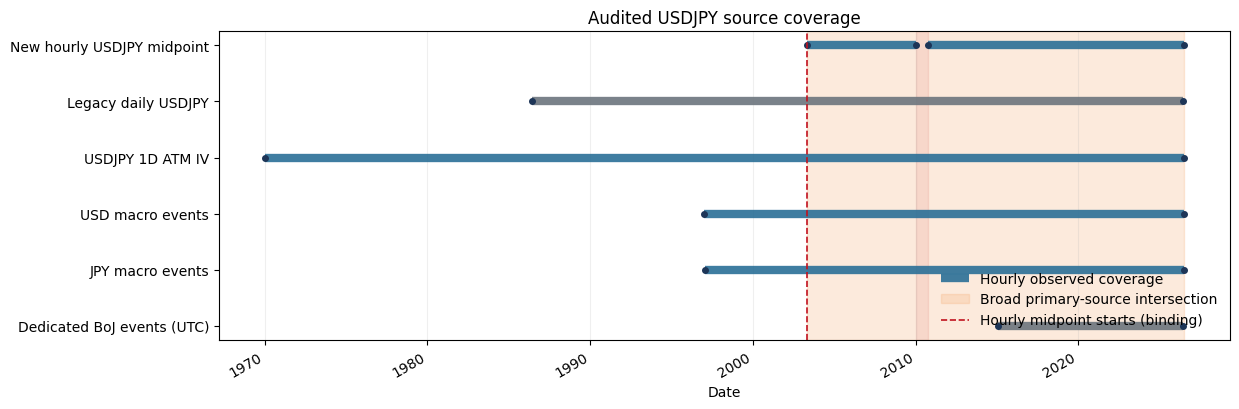

In [16]:
coverage_plot = coverage_summary.copy()
fig, ax = plt.subplots(figsize=(12.5, 4.2))
y_positions = np.arange(len(coverage_plot))[::-1]
for y, (_, row) in zip(y_positions, coverage_plot.iterrows()):
    if row['source'] == 'New hourly USDJPY midpoint':
        # Split the line into observed major coverage segments so the 2010 outage remains blank.
        for i, segment in hourly_coverage_segments.iterrows():
            ax.hlines(y, segment['segment_start_utc'].tz_localize(None), segment['segment_end_utc'].tz_localize(None), color='#2a6f97', linewidth=6, alpha=0.9, label='Hourly observed coverage' if i == 0 else None)
            ax.plot([segment['segment_start_utc'].tz_localize(None), segment['segment_end_utc'].tz_localize(None)], [y, y], 'o', color='#1d3557', markersize=4)
    else:
        ax.hlines(y, row['start'], row['end'], color='#2a6f97' if 'Primary' in row['role'] else '#6c757d', linewidth=6, alpha=0.9)
        ax.plot([row['start'], row['end']], [y, y], 'o', color='#1d3557', markersize=4)
for i, outage in major_hourly_outages.iterrows():
    ax.axvspan(outage['outage_start_utc'].tz_localize(None), outage['outage_end_utc'].tz_localize(None), color='#c1121f', alpha=0.10, label='Internal hourly outage' if i == 0 else None)
ax.axvspan(feasible_start, feasible_end, color='#f4a261', alpha=0.22, label='Broad primary-source intersection')
ax.axvline(hourly_start, color='#c1121f', linestyle='--', linewidth=1.2, label='Hourly midpoint starts (binding)')
ax.set_yticks(y_positions, coverage_plot['source'])
ax.set_title('Audited USDJPY source coverage')
ax.set_xlabel('Date')
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right', frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


The new hourly midpoint series determines the broad primary-sample start, but its line is deliberately split around the 2010 internal outage. The broad interval is therefore an outer date range, not a claim of uninterrupted intraday coverage; sparse event dates are not expanded into daily model observations here.


## 10. Model-day / timestamp alignment problem

Later work must map intraday USDJPY observations, daily realised variance, daily 1D implied volatility, and exact scheduled-event timestamps onto one model day. The new hourly timestamp strings visibly carry `+00:00`, so they are parsed as UTC. The event column is named UTC and is parsed as UTC. The ATM workbook supplies dates but no demonstrated fixing timestamp/timezone; the old daily workbook likewise exposes dates but not a supported cut. These unresolved metadata points are recorded rather than guessed.

No final daily cut is chosen in this notebook. In particular, a US release may be before or after the unknown IV quote cut, and a Japanese local date can differ from its UTC date.


## 11. Event-to-observation alignment diagnostics

The diagnostics below quantify date-level choices that will matter later—same-date availability, next available IV date, non-trading-date effects, and local-versus-UTC BoJ dates. They intentionally do not create final lags, event features, or impose any legacy 1-week-IV timing result.


In [17]:
iv_dates = pd.DatetimeIndex(atm_1d['date'].dropna().dt.normalize().unique()).sort_values()
common_start, common_end = feasible_start.normalize(), feasible_end.normalize()
def event_iv_alignment_diagnostic(events, label):
    all_dates = pd.to_datetime(events['event_date_utc'], errors='coerce').dropna().dt.tz_localize(None).dt.normalize()
    dates = all_dates.loc[all_dates.between(common_start, common_end)]
    same_date = dates.isin(iv_dates)
    next_indices = iv_dates.searchsorted(dates, side='left')
    next_dates = pd.Series(pd.NaT, index=dates.index, dtype='datetime64[ns]')
    valid = next_indices < len(iv_dates)
    next_dates.loc[valid] = iv_dates.take(next_indices[valid]).values
    wait_days = (next_dates - dates).dt.days
    return {'event_group': label, 'events_in_common_sample': len(dates), 'events_excluded_outside_common_sample': len(all_dates) - len(dates),
            'same_calendar_date_has_iv': int(same_date.sum()), 'next_iv_available_for_events': int(next_dates.notna().sum()),
            'earliest_next_available_iv_date': next_dates.min(), 'latest_next_available_iv_date': next_dates.max(),
            'median_wait_days': wait_days.median(), 'p95_wait_days': wait_days.quantile(0.95), 'max_wait_days': wait_days.max()}
event_alignment_summary = pd.DataFrame([
    event_iv_alignment_diagnostic(usd_events, 'USD events'),
    event_iv_alignment_diagnostic(jpy_events, 'JPY events'),
])
display(event_alignment_summary)
key_event_specs = [('USD', 'FOMC Rate Decision (Upper Bound)'), ('JPY', 'BOJ Target Rate')]
key_event_coverage_rows = []
for key_ccy, key_event in key_event_specs:
    event_dates = g10.loc[(g10[currency_col].eq(key_ccy)) & (g10[event_name_col].eq(key_event)), 'event_datetime_utc'].dropna().dt.tz_localize(None).dt.normalize()
    usable_dates = event_dates.loc[event_dates.between(common_start, common_end)]
    in_major_outage = sum(any(start.tz_localize(None).normalize() <= date <= end.tz_localize(None).normalize() for start, end in zip(major_hourly_outages['outage_start_utc'], major_hourly_outages['outage_end_utc'])) for date in usable_dates)
    key_event_coverage_rows.append({'currency': key_ccy, 'event_name': key_event, 'first_event_date_in_usable_sample': usable_dates.min(),
                                    'last_event_date_in_usable_sample': usable_dates.max(), 'occurrences_in_usable_sample': len(usable_dates),
                                    'inside_major_hourly_outage': in_major_outage, 'same_day_1D_IV_available': int(usable_dates.isin(iv_dates).sum())})
key_event_coverage = pd.DataFrame(key_event_coverage_rows)
display(key_event_coverage)
display(boj_timezone_audit.loc[boj_timezone_audit['utc_date_differs_from_local']].head(15))
print('Headline waits use only the common empirical interval. Unrestricted pre-sample event mappings can mechanically create multi-year waits to the first IV observation and are excluded.')
print('Conclusion: same-date versus next-available-IV treatment, weekends/holidays, BoJ UTC date shifts, and the unresolved IV cut are explicit Notebook 15 design decisions—not labels fixed here.')


,event_group,events_in_common_sample,events_excluded_outside_common_sample,same_calendar_date_has_iv,next_iv_available_for_events,earliest_next_available_iv_date,latest_next_available_iv_date,median_wait_days,p95_wait_days,max_wait_days
0,USD events,10380,1750,9887,10380,2003-05-06,2026-07-01,0.0,0.0,13
1,JPY events,4435,315,3941,4435,2003-05-13,2026-07-01,0.0,1.0,12


,currency,event_name,first_event_date_in_usable_sample,last_event_date_in_usable_sample,occurrences_in_usable_sample,inside_major_hourly_outage,same_day_1D_IV_available
0,USD,FOMC Rate Decision (Upper Bound),2003-05-06,2026-06-17,189,6,177
1,JPY,BOJ Target Rate,2006-08-11,2026-06-16,221,11,221


,Date (dd/mm/yyyy),Time (JST),local_datetime,jst_datetime,utc_datetime,local_calendar_date,utc_calendar_date,utc_date_differs_from_local
0,16/06/2026,08:30,2026-06-16 08:30:00,2026-06-16 08:30:00+09:00,2026-06-15 23:30:00+00:00,2026-06-16,2026-06-15,True
1,28/04/2026,08:30,2026-04-28 08:30:00,2026-04-28 08:30:00+09:00,2026-04-27 23:30:00+00:00,2026-04-28,2026-04-27,True
2,19/03/2026,08:30,2026-03-19 08:30:00,2026-03-19 08:30:00+09:00,2026-03-18 23:30:00+00:00,2026-03-19,2026-03-18,True
3,23/01/2026,08:30,2026-01-23 08:30:00,2026-01-23 08:30:00+09:00,2026-01-22 23:30:00+00:00,2026-01-23,2026-01-22,True
5,19/12/2025,08:30,2025-12-19 08:30:00,2025-12-19 08:30:00+09:00,2025-12-18 23:30:00+00:00,2025-12-19,2025-12-18,True
6,30/10/2025,08:30,2025-10-30 08:30:00,2025-10-30 08:30:00+09:00,2025-10-29 23:30:00+00:00,2025-10-30,2025-10-29,True
8,19/09/2025,08:30,2025-09-19 08:30:00,2025-09-19 08:30:00+09:00,2025-09-18 23:30:00+00:00,2025-09-19,2025-09-18,True
9,31/07/2025,08:30,2025-07-31 08:30:00,2025-07-31 08:30:00+09:00,2025-07-30 23:30:00+00:00,2025-07-31,2025-07-30,True
10,17/06/2025,08:30,2025-06-17 08:30:00,2025-06-17 08:30:00+09:00,2025-06-16 23:30:00+00:00,2025-06-17,2025-06-16,True
11,01/05/2025,08:30,2025-05-01 08:30:00,2025-05-01 08:30:00+09:00,2025-04-30 23:30:00+00:00,2025-05-01,2025-04-30,True


Headline waits use only the common empirical interval. Unrestricted pre-sample event mappings can mechanically create multi-year waits to the first IV observation and are excluded.
Conclusion: same-date versus next-available-IV treatment, weekends/holidays, BoJ UTC date shifts, and the unresolved IV cut are explicit Notebook 15 design decisions—not labels fixed here.


### Representative USDJPY / 1D ATM IV event-alignment check

This is a descriptive timing sanity check for the exact G10 categories `FOMC Rate Decision (Upper Bound)` and `BOJ Target Rate`. **No event effect is estimated, no causal interpretation is made, and no lag is selected.** The preliminary old −4/−5 findings used 1W IV and are not imposed on this 1D framework; formal dependence and event analysis are deferred to later notebooks.


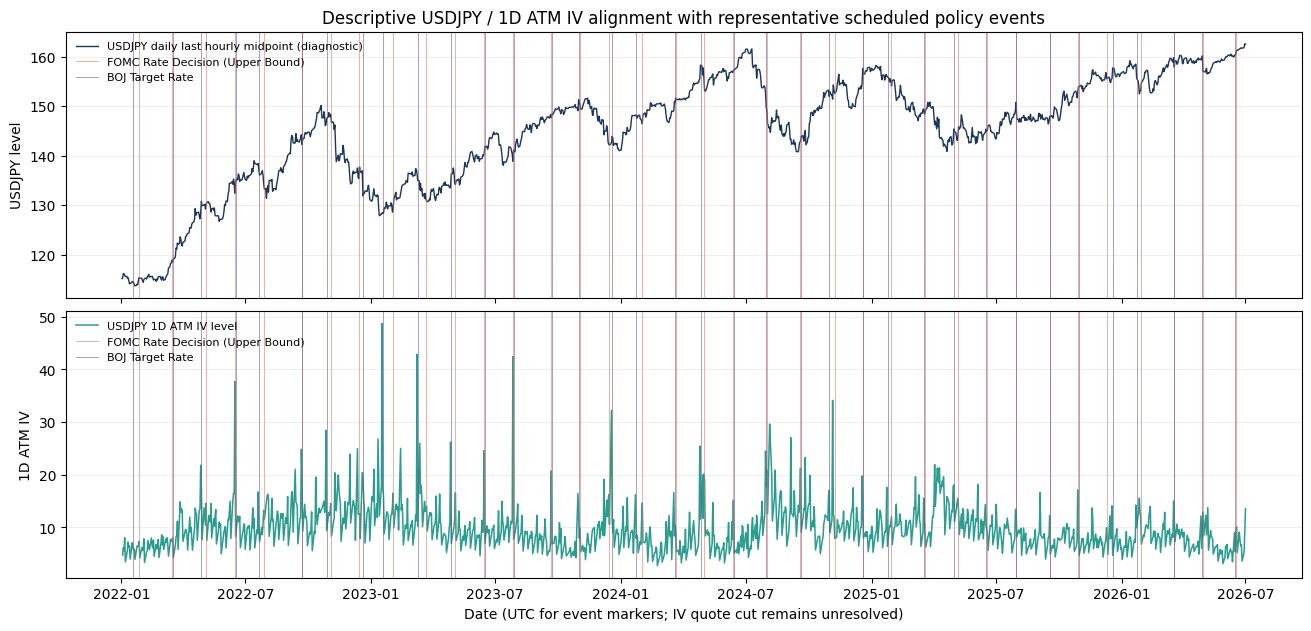

In [18]:
ALIGNMENT_PLOT_START = pd.Timestamp('2022-01-01')
ALIGNMENT_PLOT_END = min(pd.Timestamp('2026-07-01'), hourly_end, iv_end)
FOMC_EVENT_NAME = 'FOMC Rate Decision (Upper Bound)'
BOJ_EVENT_NAME = 'BOJ Target Rate'
spot_for_plot = (mid[['timestamp_parsed', close_col]].dropna().assign(plot_date=lambda x: x['timestamp_parsed'].dt.tz_localize(None))
                 .set_index('plot_date')[close_col].resample('D').last().dropna().loc[ALIGNMENT_PLOT_START:ALIGNMENT_PLOT_END])
iv_for_plot = atm_1d.set_index('date')['iv'].dropna().loc[ALIGNMENT_PLOT_START:ALIGNMENT_PLOT_END]
event_times_naive = g10.assign(plot_datetime=g10['event_datetime_utc'].dt.tz_localize(None))
fomc_plot_events = event_times_naive.loc[(event_times_naive[currency_col].eq('USD')) & (event_times_naive[event_name_col].eq(FOMC_EVENT_NAME))
                                          & event_times_naive['plot_datetime'].between(ALIGNMENT_PLOT_START, ALIGNMENT_PLOT_END), 'plot_datetime']
boj_plot_events = event_times_naive.loc[(event_times_naive[currency_col].eq('JPY')) & (event_times_naive[event_name_col].eq(BOJ_EVENT_NAME))
                                         & event_times_naive['plot_datetime'].between(ALIGNMENT_PLOT_START, ALIGNMENT_PLOT_END), 'plot_datetime']
fig, axes = plt.subplots(2, 1, figsize=(13, 6.2), sharex=True, constrained_layout=True)
spot_alignment_plot_gaps = plot_observed_segments(axes[0], spot_for_plot.index, spot_for_plot.values, label='USDJPY daily last hourly midpoint (diagnostic)', color='#1d3557', linewidth=1.0)
iv_alignment_plot_gaps = plot_observed_segments(axes[1], iv_for_plot.index, iv_for_plot.values, label='USDJPY 1D ATM IV level', color='#2a9d8f', linewidth=1.1)
for ax in axes:
    for i, event_time in enumerate(fomc_plot_events):
        ax.axvline(event_time, color='#e76f51', linewidth=0.7, alpha=0.55, label=FOMC_EVENT_NAME if i == 0 else None)
    for i, event_time in enumerate(boj_plot_events):
        ax.axvline(event_time, color='#6a4c93', linewidth=0.7, alpha=0.55, label=BOJ_EVENT_NAME if i == 0 else None)
    ax.legend(loc='upper left', frameon=False, fontsize=8)
    ax.grid(axis='y', alpha=0.2)
axes[0].set_title('Descriptive USDJPY / 1D ATM IV alignment with representative scheduled policy events')
axes[0].set_ylabel('USDJPY level')
axes[1].set_ylabel('1D ATM IV')
axes[1].set_xlabel('Date (UTC for event markers; IV quote cut remains unresolved)')
plt.show()


Vertical lines indicate timestamp presence only. The figure does not infer whether an event is incorporated into the same IV date, the next IV date, or a later model day; that depends on the still-unresolved IV quote cut and the documented model-day choice.


## 12. Data-quality and metadata synthesis

Each issue is shown with the consequence and planned handling. Severity is an audit judgment, not an instruction to silently repair raw data.


In [19]:
quality_issues = pd.DataFrame([
    ('Hourly sampling gaps', 'New hourly midpoint', 'Medium', 'Classified', f"{int(expected_weekend_gap.sum())} expected Friday-to-Sunday/Monday closures; {int(unexpected_weekday_gap.sum())} short weekday/other gaps; {int(major_discontinuity_mask.sum())} major break(s) >7 days. Enforce adjacency in Notebook 15."),
    ('Populated weekend / stale timestamps', 'New hourly midpoint', 'Medium', 'Observed', weekend_stale_description + ' Later construction must avoid treating carry-forward weekend quotes as genuine trading-hour intervals.'),
    ('Major internal hourly outage', 'New hourly midpoint', 'High', 'Observed', f"Hourly observations are absent across {major_outage_description}. Do not bridge this interval when constructing returns, realised variance, or lags."),
    ('Supplied-return-across-gap risk', 'New hourly midpoint', 'High' if int(supplied_return_diagnostic.iloc[0]['supplied_returns_across_gaps_over_one_hour']) else 'Low', 'Flagged' if int(supplied_return_diagnostic.iloc[0]['supplied_returns_across_gaps_over_one_hour']) else 'Not observed', 'Do not use supplied return; recompute only across adjacent observations in Notebook 15.'),
    ('Hourly timestamp timezone', 'New hourly midpoint', 'Low', 'Resolved from source strings', 'Strings include +00:00 and are parsed as UTC.'),
    ('Hourly OHLC / spread integrity', 'New hourly midpoint and bid/ask files', 'High' if (ohlc_integrity.to_numpy().sum() + int(supplied_spread_integrity['negative_spreads'].fillna(0).sum()) + int(quote_consistency.iloc[0]['crossed_bid_ask_close_quotes'])) else 'Low', 'Audited', 'OHLC violations and negative/zero spreads are reported. Invalid crossed quotes must be explicitly excluded or handled before primary return/RV construction.'),
    ('1D ATM quote cut/timezone', 'Bloomberg ATM PX_LAST', 'High', 'Partially resolved', 'Ticker, field and percent-quote interpretation are known; exact daily snapshot/fixing time, timezone and horizon-date label remain unresolved. Do not invent a fixing time.'),
    ('1D ATM horizon / total-variance convention', 'Bloomberg ATM PX_LAST', 'High', 'Unresolved', '`(q/100)^2` is a clean annualised variance-rate representation, but total variance requires unresolved overnight horizon/day-count, weekend and holiday conventions. Do not assume 1/252 or 1/365.'),
    ('Extraction reproducibility metadata', 'Dukascopy / Bloomberg', 'Medium', 'Partially unresolved', 'Dukascopy download version was not captured; Bloomberg overrides do not document snapshot time or overnight-expiry/day-count metadata.'),
    ('Long 1D ATM date gaps', 'ATM workbook', 'Medium', 'Audited', f"{len(iv_large_date_gaps)} gaps exceed a standard weekend; maximum {iv_gap_summary.iloc[0]['maximum_iv_date_gap_days']:.0f} days. Do not carry events forward arbitrarily over long quote gaps."),
    ('Daily spot cut', 'Legacy daily workbook', 'Medium', 'Unresolved', 'Use only as supplementary cross-check unless reliable metadata is supplied.'),
    ('BoJ local-date / UTC-date conversion', 'Dedicated BoJ calendar', 'Medium', 'Diagnosed', str(int(boj['utc_date_differs_from_local'].sum())) + ' rows change calendar date after full JST-to-UTC conversion; retain both dates.'),
    ('BoJ timestamp-source hierarchy', 'Dedicated BoJ and Bloomberg G10', 'Medium', 'Clarified', 'Dedicated calendar is a meeting-date/timezone cross-check; Bloomberg G10 BOJ Target Rate remains the primary empirical release timestamp unless source documentation changes this.'),
    ('Bad / crossed quotes', 'New and legacy bid/ask', 'Medium' if (int(quote_consistency.iloc[0]['crossed_bid_ask_close_quotes']) + int(legacy_spot_summary['crossed_bid_ask'].fillna(0).sum())) else 'Low', 'Reported', 'No quote cleaning is performed in this audit.'),
    ('Event datetime parsing', 'G10 event calendar', 'Medium' if int(g10['event_datetime_utc'].isna().sum()) else 'Low', 'Diagnosed', 'Use parsed UTC timestamps and retain any unparseable raw records for review.'),
    ('Bloomberg-derived relevance / surprise_z', 'G10 Bloomberg export', 'High', 'Construction unresolved', 'Definitions are not documented in supplied data. Do not treat as transparent modelling/OOS inputs; isolate post-announcement fields from pre-event forecasts.'),
    ('Missing observations', 'All primary sources', 'Medium', 'Diagnosed', 'Notebook 15 must apply documented availability and adjacency rules.'),
    ('RR/BF not currently required', '25R/25B workbooks', 'Low', 'Intentional exclusion', 'Inventory only; current empirical workflow is ATM 1D.'),
    ('25B 1W ticker anomaly', '25B workbook', 'High' if bf_1w_appears_rr else 'Medium', bf_1w_quarantine.iloc[0]['status'], '1W BF sheet appears to carry 25R1W-style tickers; quarantined pending source resolution.'),
    ('Equation (5)', 'Volatility surface', 'Low', 'Intentional exclusion', 'No surface interpolation is implemented.'),
], columns=['Issue', 'Source', 'Severity', 'Status', 'Consequence / planned handling'])
display(quality_issues)


,Issue,Source,Severity,Status,Consequence / planned handling
0,Hourly sampling gaps,New hourly midpoint,Medium,Classified,978 expected Friday-to-Sunday/Monday closures;...
1,Populated weekend / stale timestamps,New hourly midpoint,Medium,Observed,Weekend timestamps account for 8.1% of all row...
2,Major internal hourly outage,New hourly midpoint,High,Observed,Hourly observations are absent across 2010-01-...
3,Supplied-return-across-gap risk,New hourly midpoint,High,Flagged,Do not use supplied return; recompute only acr...
4,Hourly timestamp timezone,New hourly midpoint,Low,Resolved from source strings,Strings include +00:00 and are parsed as UTC.
5,Hourly OHLC / spread integrity,New hourly midpoint and bid/ask files,High,Audited,OHLC violations and negative/zero spreads are ...
6,1D ATM quote cut/timezone,Bloomberg ATM PX_LAST,High,Partially resolved,"Ticker, field and percent-quote interpretation..."
7,1D ATM horizon / total-variance convention,Bloomberg ATM PX_LAST,High,Unresolved,`(q/100)^2` is a clean annualised variance-rat...
8,Extraction reproducibility metadata,Dukascopy / Bloomberg,Medium,Partially unresolved,Dukascopy download version was not captured; B...
9,Long 1D ATM date gaps,ATM workbook,Medium,Audited,306 gaps exceed a standard weekend; maximum 10...


## 13. Export audit artefacts

Only lightweight audit artefacts are written to `Data/interim/`. They contain inventory, coverage, quality synthesis, and transparent BoJ timezone diagnostics—not cleaned returns, realised variance, implied variance, event features, or a modelling panel.


In [20]:
hourly_audited_columns = [timestamp_col, 'timestamp_parsed', 'mid_open', 'mid_high', 'mid_low', close_col, spread_col,
                          'is_adjacent_hour_diagnostic', 'gap_classification', 'major_coverage_segment']
hourly_audited_columns = [column for column in hourly_audited_columns if column is not None and column in mid.columns]
usdjpy_hourly_mid_audited = mid[hourly_audited_columns].copy()  # raw-level prices and audit flags only; no constructed returns/RV
usdjpy_atm_1d_audited = atm_1d[['date', 'iv', 'date_diff']].copy()
usdjpy_atm_1d_audited['prior_iv_gap_over_3_days'] = usdjpy_atm_1d_audited['date_diff'].gt(pd.Timedelta(days=3))
g10_usd_jpy_events_audited = g10.loc[g10[currency_col].isin(['USD', 'JPY'])].copy()
g10_usd_jpy_events_audited['event_datetime_parse_ok'] = g10_usd_jpy_events_audited['event_datetime_utc'].notna()
boj_calendar_audited = boj.copy()
exports = {
    'empirical_source_inventory.csv': source_inventory,
    'empirical_coverage_summary.csv': coverage_summary.assign(broad_feasible_start=feasible_start, broad_feasible_end=feasible_end, effective_start_driver=effective_start_driver),
    'empirical_data_quality_issues.csv': quality_issues,
    'boj_timezone_audit.csv': boj_timezone_audit,
    'usdjpy_hourly_mid_audited.csv': usdjpy_hourly_mid_audited,
    'usdjpy_atm_1d_audited.csv': usdjpy_atm_1d_audited,
    'g10_usd_jpy_events_audited.csv': g10_usd_jpy_events_audited,
    'boj_calendar_audited.csv': boj_calendar_audited,
}
for filename, frame in exports.items():
    frame.to_csv(INTERIM_DIR / filename, index=False)
for filename in exports:
    assert not pd.read_csv(INTERIM_DIR / filename).empty, f'Audited export failed to reload: {filename}'
display(pd.DataFrame({'audit_file': list(exports), 'path': [str((INTERIM_DIR / x).relative_to(PROJECT_DIR)) for x in exports]}))


,audit_file,path
0,empirical_source_inventory.csv,Data\interim\empirical_source_inventory.csv
1,empirical_coverage_summary.csv,Data\interim\empirical_coverage_summary.csv
2,empirical_data_quality_issues.csv,Data\interim\empirical_data_quality_issues.csv
3,boj_timezone_audit.csv,Data\interim\boj_timezone_audit.csv
4,usdjpy_hourly_mid_audited.csv,Data\interim\usdjpy_hourly_mid_audited.csv
5,usdjpy_atm_1d_audited.csv,Data\interim\usdjpy_atm_1d_audited.csv
6,g10_usd_jpy_events_audited.csv,Data\interim\g10_usd_jpy_events_audited.csv
7,boj_calendar_audited.csv,Data\interim\boj_calendar_audited.csv


## 14. Integrity checks

The checks below are intentionally meaningful rather than numerous: required inputs and USDJPY 1D data exist, parsing is acceptable, there is broad primary overlap, excluded 15-minute data was not loaded, and raw files are unchanged.


In [21]:
assert mid['timestamp_parsed'].notna().mean() > 0.99, 'Hourly timestamp parsing is not acceptable.'
assert len(mid) == len(mid_raw), 'Audited hourly midpoint row count changed unexpectedly.'
assert g10['event_datetime_utc'].notna().mean() > 0.99, 'G10 timestamp parsing is not acceptable.'
assert g10_fractional_timestamp_audit.iloc[0]['parsed_fractional_second_timestamps'] > 0, 'Valid G10 fractional-second timestamps were not retained.'
assert str(mid['timestamp_parsed'].dtype).endswith('UTC]') and str(g10['event_datetime_utc'].dtype).endswith('UTC]'), 'Primary UTC timestamps are not timezone-aware UTC.'
assert atm_1d['iv'].notna().any(), 'USDJPY 1D ATM IV series is empty.'
assert len(atm_1d) == len(usdjpy_atm_1d_audited), 'Audited ATM row count changed unexpectedly.'
assert 'USDJPY' in atm_1d_identifier.upper() and ATM_BLOOMBERG_FIELD == 'PX_LAST', 'Primary Bloomberg IV provenance is inconsistent.'
assert hourly_start <= iv_end and iv_start <= hourly_end, 'Hourly and 1D IV date ranges do not overlap.'
assert feasible_start <= feasible_end, 'The required broad primary overlap is empty.'
assert all('15min' not in str(path).lower() for path in RAW_PATHS.values()), 'Excluded 15-minute data appears in the audit input set.'
forbidden_model_tokens = ['return', 'rv', 'variance', 'weight', 'model_day']
assert not any(any(token in column.lower() for token in forbidden_model_tokens) for column in usdjpy_hourly_mid_audited.columns if column.lower() not in {'timestamp_diff'}), 'A final model-variable-like field entered the audited hourly export.'
RAW_HASHES_AFTER = {name: sha256_file(path) for name, path in RAW_PATHS.items()}
assert RAW_HASHES_BEFORE == RAW_HASHES_AFTER, 'A raw file changed during the audit.'
print('All integrity checks passed. Raw source SHA-256 hashes are unchanged.')


All integrity checks passed. Raw source SHA-256 hashes are unchanged.


## 15. Final go / no-go summary

The final statement is generated from the audit results rather than hard-coded. It records the selected sources, feasible broad sample, planned Notebook 15 work, and any metadata uncertainty that remains material to alignment.


In [22]:
blocking = feasible_start > feasible_end or atm_1d['iv'].notna().sum() == 0 or mid['timestamp_parsed'].notna().mean() <= 0.99
decision = 'NO-GO' if blocking else 'GO'
summary_lines = [
    f'### {decision} for Notebook 15',
    f'- **Selected primary market inputs:** new USDJPY hourly midpoint and USDJPY 1D/overnight ATM IV (`{atm_1d_identifier}`). **Primary scheduled-event source:** USD/JPY Bloomberg G10 calendar.',
    '- **Event-source hierarchy:** Bloomberg G10 is the primary scheduled-event source (including `BOJ Target Rate` release timestamps); the dedicated BoJ file is a supplementary meeting-date/timezone cross-check and is not automatically interchangeable.',
    f'- **Broad feasible sample:** {feasible_start:%Y-%m-%d} to {feasible_end:%Y-%m-%d}; effective start is determined by **{effective_start_driver}**.',
    f'- **Internal hourly availability limitation:** the broad hourly span is split by a major outage from **{major_outage_description}**. It is not a continuous 2003–2026 series.',
    '- **Notebook 15 rule:** recompute hourly log returns from `mid_close` only across valid adjacent trading observations. It must never bridge the major outage or genuine missing-data gaps, and must determine a valid trading-hour/day mask so stale/carry-forward weekend quotes do not create artificial zero-return intervals before daily realised-variance aggregation.',
    f'- **Weekend/stale-quote finding:** {weekend_stale_description} These populated timestamps are not automatically treated as genuine trading observations in downstream construction.',
    f'- **IV provenance:** Bloomberg `{ATM_PRIMARY_TICKER}` `{ATM_BLOOMBERG_FIELD}` and its percent/vol-point quote scale are known; `(q/100)^2` is an annualised variance-rate representation. The daily quote cut, snapshot timezone, overnight horizon and total-variance day-count remain unresolved—do not assume 1/252 or 1/365 or carry events arbitrarily across long IV gaps.',
    '- **Event-information rules:** use scheduled timestamp/name/currency for timing only as appropriate; do not use actuals, surprises, revisions, or unverified Bloomberg `relevance`/`surprise_z` construction in genuinely pre-event or OOS forecasts.',
    '- **Independent daily check:** the original daily USDJPY source is retained as a spot-level validation source, not as a substitute for missing intraday data or realised variance.',
    '- **Remaining alignment limitation:** the ATM 1D daily quote cut/fixing timestamp and timezone are unresolved in the workbook metadata; the legacy daily spot cut is also unresolved.',
    '- **Notebook 14 contract:** this notebook fixes source provenance, raw coverage, quality/timezone diagnostics, event reconciliation, candle timing, and downstream constraints. It does not choose the final model-day cut, return/RV/IV construction, event assignment, calibration, causality, or forecasting.',
    '- **Not carried forward as assumptions:** 15-minute data, Equation (5), RR/BF inputs, and legacy 1-week-IV event-study timing.',
]
if blocking:
    summary_lines.append('- **Blocking issue:** primary source coverage or parsing is insufficient; resolve this before variable construction.')
else:
    summary_lines.append('- **Decision:** proceed while explicitly retaining quote-cut/timezone uncertainty and the hourly-coverage rules as alignment limitations to resolve or parameterise.')
display(Markdown('\n'.join(summary_lines)))


### GO for Notebook 15
- **Selected primary market inputs:** new USDJPY hourly midpoint and USDJPY 1D/overnight ATM IV (`USDJPY`). **Primary scheduled-event source:** USD/JPY Bloomberg G10 calendar.
- **Event-source hierarchy:** Bloomberg G10 is the primary scheduled-event source (including `BOJ Target Rate` release timestamps); the dedicated BoJ file is a supplementary meeting-date/timezone cross-check and is not automatically interchangeable.
- **Broad feasible sample:** 2003-05-04 to 2026-07-01; effective start is determined by **hourly USDJPY**.
- **Internal hourly availability limitation:** the broad hourly span is split by a major outage from **2010-01-01 00:00 UTC to 2010-10-01 10:00 UTC (273.4 days)**. It is not a continuous 2003–2026 series.
- **Notebook 15 rule:** recompute hourly log returns from `mid_close` only across valid adjacent trading observations. It must never bridge the major outage or genuine missing-data gaps, and must determine a valid trading-hour/day mask so stale/carry-forward weekend quotes do not create artificial zero-return intervals before daily realised-variance aggregation.
- **Weekend/stale-quote finding:** Weekend timestamps account for 8.1% of all rows; Saturday adjacent-hour unchanged quotes are 99.6% overall and Sunday adjacent-hour unchanged quotes are 50.1% overall; materially populated weekend years are 2010, 2011, 2012, 2013, 2014. These populated timestamps are not automatically treated as genuine trading observations in downstream construction.
- **IV provenance:** Bloomberg `USDJPYVON BGN Curncy` `PX_LAST` and its percent/vol-point quote scale are known; `(q/100)^2` is an annualised variance-rate representation. The daily quote cut, snapshot timezone, overnight horizon and total-variance day-count remain unresolved—do not assume 1/252 or 1/365 or carry events arbitrarily across long IV gaps.
- **Event-information rules:** use scheduled timestamp/name/currency for timing only as appropriate; do not use actuals, surprises, revisions, or unverified Bloomberg `relevance`/`surprise_z` construction in genuinely pre-event or OOS forecasts.
- **Independent daily check:** the original daily USDJPY source is retained as a spot-level validation source, not as a substitute for missing intraday data or realised variance.
- **Remaining alignment limitation:** the ATM 1D daily quote cut/fixing timestamp and timezone are unresolved in the workbook metadata; the legacy daily spot cut is also unresolved.
- **Notebook 14 contract:** this notebook fixes source provenance, raw coverage, quality/timezone diagnostics, event reconciliation, candle timing, and downstream constraints. It does not choose the final model-day cut, return/RV/IV construction, event assignment, calibration, causality, or forecasting.
- **Not carried forward as assumptions:** 15-minute data, Equation (5), RR/BF inputs, and legacy 1-week-IV event-study timing.
- **Decision:** proceed while explicitly retaining quote-cut/timezone uncertainty and the hourly-coverage rules as alignment limitations to resolve or parameterise.